# Cluster-Based Feature Engineering for Parkinson's Disease Classification

**This notebook implements feature clustering and aggregation for improved classification performance.**

## Overview

This notebook explores the impact of feature clustering on model performance:
1. Hierarchical clustering of features based on correlation
2. Feature aggregation at multiple cluster levels with various methods (mean, PCA, max, min, std, median, sum)
3. Training and evaluation of 4 models at each cluster level (Neural Network, Random Forest, XGBoost, Logistic Regression)
4. Comprehensive comparison of results across cluster levels and aggregation methods

**All code is self-contained - no external dependencies on other notebooks.**

## 1. Setup and Imports


In [1]:
# ============================================================
# All Required Imports
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime
import pickle
from itertools import product
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

print("✓ All imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✓ All imports loaded successfully!
PyTorch version: 2.8.0+cu128
CUDA available: True


## 2. Configuration


In [2]:
# ============================================================
# Configuration
# ============================================================

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Feature selection: Acoustic only (matching baseline)
USE_PHENOTYPE_FEATURES = False

# Cluster levels to test
CLUSTER_LEVELS = [5, 10, 15, 20, 50, 70, 90, 110, 130]

# Aggregation methods to use
AGGREGATION_METHODS = ['mean', 'pca', 'max', 'min', 'std', 'median', 'sum']

# Paths
ROOT = Path.cwd()
DATA_PATH = ROOT / 'physionet.org' / 'files' / 'b2ai-voice' / '2.0.1'
OUTPUT_DIR = ROOT / 'outputs' / 'cluster_feature_engineering'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data files
PHENOTYPE_FILE = DATA_PATH / 'phenotype.tsv'
STATIC_FILE = DATA_PATH / 'static_features.tsv'

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("✓ Using MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print("✓ Using CPU")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")
print(f"Cluster levels to test: {CLUSTER_LEVELS}")
print(f"Aggregation methods: {AGGREGATION_METHODS}")


✓ Using CUDA: NVIDIA GeForce RTX 2080 Ti

Output directory: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering
Random seed: 42
Cluster levels to test: [5, 10, 15, 20, 50, 70, 90, 110, 130]
Aggregation methods: ['mean', 'pca', 'max', 'min', 'std', 'median', 'sum']


## 3. Data Loading and Preparation

This section loads and prepares the data (acoustic features only, matching the baseline notebook).


In [3]:
# ============================================================
# Load Data and Create Labels (Acoustic Features Only)
# ============================================================

print("=" * 60)
print("LOADING DATA AND CREATING LABELS")
print("=" * 60)

# Load phenotype data
if not PHENOTYPE_FILE.exists():
    raise FileNotFoundError(f"Phenotype file not found: {PHENOTYPE_FILE}")

phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep='\t', low_memory=False)
print(f"✓ Phenotype shape: {phenotype_df.shape}")

# Detect control and Parkinson's columns
control_col = None
for c in phenotype_df.columns:
    if "control" in c.lower() or "healthy" in c.lower():
        control_col = c
        break

if "parkinsons" in phenotype_df.columns:
    pd_col = "parkinsons"
elif "parkinson" in phenotype_df.columns:
    pd_col = "parkinson"
else:
    raise RuntimeError("Cannot detect Parkinson's column")

# Create labels
phenotype_df['pd_label'] = phenotype_df[pd_col].astype(str).str.lower().eq("checked").astype(int)
phenotype_df['control_label'] = phenotype_df[control_col].astype(str).str.lower().eq("yes").astype(int)
phenotype_df['label'] = phenotype_df['pd_label']
phenotype_df.loc[phenotype_df['control_label'] == 1, 'label'] = 0

# Keep only Parkinsons and controls
phenotype_df = phenotype_df[(phenotype_df['pd_label'] == 1) | (phenotype_df['control_label'] == 1)]

print(f"\n✓ Label distribution:")
print(phenotype_df['label'].value_counts())

# Load static features
if not STATIC_FILE.exists():
    raise FileNotFoundError(f"Static features file not found: {STATIC_FILE}")

static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
print(f"\n✓ Static features shape: {static_df.shape}")

# Merge datasets
merge_cols = ['participant_id', 'session_id']
if 'task_name' in static_df.columns and 'task_name' in phenotype_df.columns:
    merge_cols.append('task_name')

# Acoustic-only mode: only merge labels, no screening demographics
phenotype_cols_to_merge = merge_cols + ['label', 'pd_label']

merged_df = static_df.merge(
    phenotype_df[phenotype_cols_to_merge],
    on=merge_cols,
    how='inner'
)

print(f"\n✓ Merged dataset shape: {merged_df.shape}")
print(f"  Label distribution: {merged_df['label'].value_counts().to_dict()}")

# Get feature columns (exclude IDs and labels)
id_cols = ['participant_id', 'session_id']
if 'task_name' in merged_df.columns:
    id_cols.append('task_name')
label_cols = ['label', 'pd_label']

# Also exclude known text/transcription columns
exclude_cols = ['transcription'] if 'transcription' in merged_df.columns else []
exclude_cols.extend(['recording_id'] if 'recording_id' in merged_df.columns else [])

feature_cols = [c for c in merged_df.columns if c not in id_cols + label_cols + exclude_cols]

# Filter to only numeric columns
feature_cols = [c for c in feature_cols if merged_df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f"\n✓ Number of numeric features: {len(feature_cols)}")
if len(exclude_cols) > 0:
    print(f"  Excluded non-feature columns: {exclude_cols}")
print("=" * 60)


LOADING DATA AND CREATING LABELS
✓ Phenotype shape: (442, 1109)

✓ Label distribution:
label
0    64
1    61
Name: count, dtype: int64

✓ Static features shape: (19271, 135)

✓ Merged dataset shape: (4879, 137)
  Label distribution: {1: 2441, 0: 2438}

✓ Number of numeric features: 131
  Excluded non-feature columns: ['transcription']


## 4. Data Preprocessing and Participant-Level Splits


In [4]:
# ============================================================
# Data Cleaning and Participant-Level Splits
# ============================================================

print("=" * 60)
print("DATA CLEANING & PARTICIPANT-LEVEL SPLITS")
print("=" * 60)

# Extract features and labels
X_full = merged_df[feature_cols].copy()
y_full = merged_df['label'].astype(int).copy()
pid_full = merged_df['participant_id'].astype(str).copy()

# Filter out non-numeric columns (e.g., transcription, text columns)
print(f"\nFiltering non-numeric columns...")
numeric_cols = []
non_numeric_cols = []
for col in X_full.columns:
    if X_full[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
        numeric_cols.append(col)
    else:
        # Try to convert to numeric
        try:
            pd.to_numeric(X_full[col], errors='raise')
            numeric_cols.append(col)
        except (ValueError, TypeError):
            non_numeric_cols.append(col)

if non_numeric_cols:
    print(f"  ⚠ Removing {len(non_numeric_cols)} non-numeric columns: {non_numeric_cols[:5]}{'...' if len(non_numeric_cols) > 5 else ''}")
    X_full = X_full[numeric_cols]
    feature_cols = numeric_cols

print(f"  ✓ Using {len(feature_cols)} numeric features")

# Clean: handle NaN and Inf
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Handle missing values (all columns should be numeric now)
for col in X_full.columns:
    if X_full[col].isna().all():
        X_full[col].fillna(0, inplace=True)
    else:
        col_median = X_full[col].median()
        if pd.isna(col_median):
            X_full[col].fillna(0, inplace=True)
        else:
            X_full[col].fillna(col_median, inplace=True)

# Force fill any remaining NaN/Inf with 0
X_full = X_full.fillna(0)
X_full = X_full.replace([np.inf, -np.inf], 0)

# Participant-level splits (no data leakage)
unique_participants = pid_full.unique()
participant_labels = merged_df.groupby('participant_id')['label'].first()

# Split participants (not recordings): 60% train, 20% val, 20% test
pids_train_val, pids_test, y_p_train_val, y_p_test = train_test_split(
    unique_participants,
    participant_labels.loc[unique_participants],
    test_size=0.2,
    random_state=SEED,
    stratify=participant_labels.loc[unique_participants]
)

pids_train, pids_val, y_p_train, y_p_val = train_test_split(
    pids_train_val,
    y_p_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=y_p_train_val
)

# Map participant splits to recording level
train_mask = pid_full.isin(pids_train)
val_mask = pid_full.isin(pids_val)
test_mask = pid_full.isin(pids_test)

X_train_raw = X_full[train_mask].copy()
X_val_raw = X_full[val_mask].copy()
X_test_raw = X_full[test_mask].copy()

y_train_raw = y_full[train_mask].copy()
y_val_raw = y_full[val_mask].copy()
y_test_raw = y_full[test_mask].copy()

pid_train = pid_full[train_mask].values
pid_val = pid_full[val_mask].values
pid_test = pid_full[test_mask].values

print(f"\n✓ Recording-level splits:")
print(f"  Train: {len(X_train_raw)} (Control: {(y_train_raw == 0).sum()}, PD: {(y_train_raw == 1).sum()})")
print(f"  Val:   {len(X_val_raw)} (Control: {(y_val_raw == 0).sum()}, PD: {(y_val_raw == 1).sum()})")
print(f"  Test:  {len(X_test_raw)} (Control: {(y_test_raw == 0).sum()}, PD: {(y_test_raw == 1).sum()})")
print(f"\n✓ Unique participants per split:")
print(f"  Train: {len(np.unique(pid_train))}, Val: {len(np.unique(pid_val))}, Test: {len(np.unique(pid_test))}")

# Ensure all values are numeric (convert to float)
print(f"\nConverting to numeric arrays...")
X_train_raw = X_train_raw.astype(np.float32)
X_val_raw = X_val_raw.astype(np.float32)
X_test_raw = X_test_raw.astype(np.float32)

# Standardize using training data only
print(f"Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.values)
X_val_scaled = scaler.transform(X_val_raw.values)
X_test_scaled = scaler.transform(X_test_raw.values)

# Clip extreme values
X_train_scaled = np.clip(X_train_scaled, -8.0, 8.0)
X_val_scaled = np.clip(X_val_scaled, -8.0, 8.0)
X_test_scaled = np.clip(X_test_scaled, -8.0, 8.0)

print(f"\n✓ Data standardized and clipped")
print(f"  Original feature count: {len(feature_cols)}")
print("=" * 60)


DATA CLEANING & PARTICIPANT-LEVEL SPLITS

Filtering non-numeric columns...
  ✓ Using 131 numeric features

✓ Recording-level splits:
  Train: 3071 (Control: 1514, PD: 1557)
  Val:   832 (Control: 411, PD: 421)
  Test:  976 (Control: 513, PD: 463)

✓ Unique participants per split:
  Train: 80, Val: 20, Test: 25

Converting to numeric arrays...
Standardizing features...

✓ Data standardized and clipped
  Original feature count: 131


## 5. Feature Clustering Functions

This section implements hierarchical clustering of features based on correlation.


In [5]:
# ============================================================
# Feature Clustering Functions
# ============================================================

def compute_correlation_matrix(X, feature_names):
    """
    Compute correlation matrix and distance matrix for features.
    
    Parameters:
    -----------
    X : np.ndarray, shape (n_samples, n_features)
        Feature matrix
    feature_names : list
        List of feature names
        
    Returns:
    --------
    corr_matrix : np.ndarray
        Correlation matrix
    corr_dist : np.ndarray
        Distance matrix (1 - |correlation|)
    """
    print(f"Computing correlation matrix for {len(feature_names)} features...")
    
    # Compute correlation
    corr_matrix = np.corrcoef(X.T)
    
    # Handle NaN/Inf
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=1.0, neginf=-1.0)
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    
    # Convert to distance matrix (1 - |correlation|)
    corr_dist = 1 - np.abs(corr_matrix)
    corr_dist = np.nan_to_num(corr_dist, nan=1.0, posinf=1.0, neginf=1.0)
    corr_dist = np.clip(corr_dist, 0.0, 2.0)
    corr_dist = (corr_dist + corr_dist.T) / 2.0  # Make symmetric
    np.fill_diagonal(corr_dist, 0.0)  # Distance to self is 0
    
    print(f"✓ Correlation matrix computed: {corr_matrix.shape}")
    return corr_matrix, corr_dist


def cluster_features(X_train, feature_names, n_clusters, corr_matrix=None, corr_dist=None):
    """
    Perform hierarchical clustering of features.
    
    Parameters:
    -----------
    X_train : np.ndarray
        Training feature matrix
    feature_names : list
        List of feature names
    n_clusters : int
        Number of clusters
    corr_matrix : np.ndarray, optional
        Pre-computed correlation matrix
    corr_dist : np.ndarray, optional
        Pre-computed distance matrix
        
    Returns:
    --------
    cluster_labels : np.ndarray
        Cluster assignment for each feature
    linkage_matrix : np.ndarray
        Linkage matrix from hierarchical clustering
    """
    print(f"\nClustering {len(feature_names)} features into {n_clusters} clusters...")
    
    # Compute correlation if not provided
    if corr_matrix is None or corr_dist is None:
        corr_matrix, corr_dist = compute_correlation_matrix(X_train, feature_names)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(squareform(corr_dist, checks=False), method='ward')
    
    # Get cluster assignments
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    # Create cluster assignment DataFrame
    cluster_df = pd.DataFrame({
        'feature': feature_names,
        'cluster': cluster_labels
    })
    
    print(f"✓ Features clustered into {n_clusters} clusters")
    print(f"  Cluster sizes:")
    cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
    for cluster_id, size in cluster_sizes.head(10).items():
        print(f"    Cluster {cluster_id}: {size} features")
    if len(cluster_sizes) > 10:
        print(f"    ... (showing top 10, {len(cluster_sizes)} total clusters)")
    
    return cluster_labels, linkage_matrix, cluster_df

print("✓ Feature clustering functions defined")


✓ Feature clustering functions defined


## 6. Feature Aggregation Functions

This section implements functions to aggregate features within clusters.


In [6]:
# ============================================================
# Feature Aggregation Functions
# ============================================================

def aggregate_features_mean(X, cluster_labels, n_clusters):
    """
    Aggregate features within each cluster using mean.
    
    Parameters:
    -----------
    X : np.ndarray, shape (n_samples, n_features)
        Feature matrix
    cluster_labels : np.ndarray, shape (n_features,)
        Cluster assignment for each feature
    n_clusters : int
        Number of clusters
        
    Returns:
    --------
    X_aggregated : np.ndarray, shape (n_samples, n_clusters)
        Aggregated feature matrix
    """
    n_samples = X.shape[0]
    X_aggregated = np.zeros((n_samples, n_clusters))
    
    for cluster_id in range(1, n_clusters + 1):  # Clusters are 1-indexed
        cluster_mask = cluster_labels == cluster_id
        if cluster_mask.sum() > 0:
            # Mean aggregation
            X_aggregated[:, cluster_id - 1] = X[:, cluster_mask].mean(axis=1)
        # If no features in cluster, leave as zero
    
    return X_aggregated


def aggregate_features_pca(X_train, X_val, X_test, cluster_labels, n_clusters, n_components=1):
    """
    Aggregate features within each cluster using PCA (first principal component).
    
    Parameters:
    -----------
    X_train : np.ndarray
        Training feature matrix
    X_val : np.ndarray
        Validation feature matrix
    X_test : np.ndarray
        Test feature matrix
    cluster_labels : np.ndarray
        Cluster assignment for each feature
    n_clusters : int
        Number of clusters
    n_components : int
        Number of PCA components to use per cluster (default: 1)
        
    Returns:
    --------
    X_train_agg : np.ndarray
        Aggregated training features
    X_val_agg : np.ndarray
        Aggregated validation features
    X_test_agg : np.ndarray
        Aggregated test features
    pca_models : list
        List of PCA models (one per cluster)
    """
    n_train_samples = X_train.shape[0]
    n_val_samples = X_val.shape[0]
    n_test_samples = X_test.shape[0]
    
    X_train_agg = np.zeros((n_train_samples, n_clusters * n_components))
    X_val_agg = np.zeros((n_val_samples, n_clusters * n_components))
    X_test_agg = np.zeros((n_test_samples, n_clusters * n_components))
    
    pca_models = []
    col_idx = 0
    
    for cluster_id in range(1, n_clusters + 1):  # Clusters are 1-indexed
        cluster_mask = cluster_labels == cluster_id
        n_features_in_cluster = cluster_mask.sum()
        
        if n_features_in_cluster > 0:
            # Extract features for this cluster
            X_train_cluster = X_train[:, cluster_mask]
            X_val_cluster = X_val[:, cluster_mask]
            X_test_cluster = X_test[:, cluster_mask]
            
            # Apply PCA
            if n_features_in_cluster == 1:
                # Single feature: just use it directly
                X_train_agg[:, col_idx] = X_train_cluster[:, 0]
                X_val_agg[:, col_idx] = X_val_cluster[:, 0]
                X_test_agg[:, col_idx] = X_test_cluster[:, 0]
                pca_models.append(None)
                col_idx += 1
            else:
                # Multiple features: use PCA
                pca = PCA(n_components=min(n_components, n_features_in_cluster))
                X_train_cluster_pca = pca.fit_transform(X_train_cluster)
                X_val_cluster_pca = pca.transform(X_val_cluster)
                X_test_cluster_pca = pca.transform(X_test_cluster)
                
                # Store PCA components
                for comp_idx in range(X_train_cluster_pca.shape[1]):
                    X_train_agg[:, col_idx] = X_train_cluster_pca[:, comp_idx]
                    X_val_agg[:, col_idx] = X_val_cluster_pca[:, comp_idx]
                    X_test_agg[:, col_idx] = X_test_cluster_pca[:, comp_idx]
                    col_idx += 1
                
                pca_models.append(pca)
        # If no features in cluster, leave as zero
    
    return X_train_agg, X_val_agg, X_test_agg, pca_models


def aggregate_features_generic(X, cluster_labels, n_clusters, agg_func):
    """
    Generic aggregation function that applies a function to features within each cluster.
    
    Parameters:
    -----------
    X : np.ndarray, shape (n_samples, n_features)
        Feature matrix
    cluster_labels : np.ndarray, shape (n_features,)
        Cluster assignment for each feature
    n_clusters : int
        Number of clusters
    agg_func : callable
        Aggregation function (e.g., np.mean, np.max, np.min, np.std, np.median, np.sum)
        
    Returns:
    --------
    X_aggregated : np.ndarray, shape (n_samples, n_clusters)
        Aggregated feature matrix
    """
    n_samples = X.shape[0]
    X_aggregated = np.zeros((n_samples, n_clusters))
    
    for cluster_id in range(1, n_clusters + 1):  # Clusters are 1-indexed
        cluster_mask = cluster_labels == cluster_id
        if cluster_mask.sum() > 0:
            X_aggregated[:, cluster_id - 1] = agg_func(X[:, cluster_mask], axis=1)
        # If no features in cluster, leave as zero
    
    return X_aggregated


def aggregate_features_max(X, cluster_labels, n_clusters):
    """Aggregate features using max."""
    return aggregate_features_generic(X, cluster_labels, n_clusters, np.max)


def aggregate_features_min(X, cluster_labels, n_clusters):
    """Aggregate features using min."""
    return aggregate_features_generic(X, cluster_labels, n_clusters, np.min)


def aggregate_features_std(X, cluster_labels, n_clusters):
    """Aggregate features using standard deviation."""
    return aggregate_features_generic(X, cluster_labels, n_clusters, np.std)


def aggregate_features_median(X, cluster_labels, n_clusters):
    """Aggregate features using median."""
    return aggregate_features_generic(X, cluster_labels, n_clusters, np.median)


def aggregate_features_sum(X, cluster_labels, n_clusters):
    """Aggregate features using sum."""
    return aggregate_features_generic(X, cluster_labels, n_clusters, np.sum)


def aggregate_features(X_train, X_val, X_test, cluster_labels, n_clusters, method='mean'):
    """
    Aggregate features using the specified method.
    
    Parameters:
    -----------
    X_train, X_val, X_test : np.ndarray
        Feature matrices
    cluster_labels : np.ndarray
        Cluster assignment for each feature
    n_clusters : int
        Number of clusters
    method : str
        Aggregation method: 'mean', 'pca', 'max', 'min', 'std', 'median', or 'sum'
        
    Returns:
    --------
    Aggregated feature matrices
    """
    if method == 'mean':
        X_train_agg = aggregate_features_mean(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_mean(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_mean(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    elif method == 'pca':
        return aggregate_features_pca(X_train, X_val, X_test, cluster_labels, n_clusters)
    elif method == 'max':
        X_train_agg = aggregate_features_max(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_max(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_max(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    elif method == 'min':
        X_train_agg = aggregate_features_min(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_min(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_min(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    elif method == 'std':
        X_train_agg = aggregate_features_std(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_std(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_std(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    elif method == 'median':
        X_train_agg = aggregate_features_median(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_median(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_median(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    elif method == 'sum':
        X_train_agg = aggregate_features_sum(X_train, cluster_labels, n_clusters)
        X_val_agg = aggregate_features_sum(X_val, cluster_labels, n_clusters)
        X_test_agg = aggregate_features_sum(X_test, cluster_labels, n_clusters)
        return X_train_agg, X_val_agg, X_test_agg, None
    else:
        raise ValueError(f"Unknown aggregation method: {method}. Use 'mean', 'pca', 'max', 'min', 'std', 'median', or 'sum'.")

print("✓ Feature aggregation functions defined")


✓ Feature aggregation functions defined


## 7. Perform Feature Clustering and Aggregation

This section performs clustering and aggregation at all specified cluster levels.


In [7]:
# ============================================================
# Perform Feature Clustering at All Levels
# ============================================================

print("=" * 60)
print("FEATURE CLUSTERING AND AGGREGATION")
print("=" * 60)

# Compute correlation matrix once (reused for all cluster levels)
print("\nStep 1: Computing correlation matrix...")
corr_matrix, corr_dist = compute_correlation_matrix(X_train_scaled, feature_cols)

# Store clustering results
clustering_results = {}

# Perform clustering at each level
print("\n" + "=" * 60)
print("Step 2: Performing clustering at all levels...")
print("=" * 60)

for n_clusters in CLUSTER_LEVELS:
    print(f"\n{'='*60}")
    print(f"CLUSTER LEVEL: {n_clusters}")
    print(f"{'='*60}")
    
    # Cluster features
    cluster_labels, linkage_matrix, cluster_df = cluster_features(
        X_train_scaled, feature_cols, n_clusters, 
        corr_matrix=corr_matrix, corr_dist=corr_dist
    )
    
    # Store clustering result
    clustering_results[n_clusters] = {
        'cluster_labels': cluster_labels,
        'linkage_matrix': linkage_matrix,
        'cluster_df': cluster_df
    }
    
    # Save cluster assignments
    cluster_df.to_csv(OUTPUT_DIR / f'cluster_assignments_{n_clusters}.csv', index=False)
    print(f"✓ Saved cluster assignments to: {OUTPUT_DIR / f'cluster_assignments_{n_clusters}.csv'}")

print("\n" + "=" * 60)
print("✓ Clustering completed for all levels")
print("=" * 60)


FEATURE CLUSTERING AND AGGREGATION

Step 1: Computing correlation matrix...
Computing correlation matrix for 131 features...
✓ Correlation matrix computed: (131, 131)

Step 2: Performing clustering at all levels...

CLUSTER LEVEL: 5

Clustering 131 features into 5 clusters...
✓ Features clustered into 5 clusters
  Cluster sizes:
    Cluster 1: 19 features
    Cluster 2: 23 features
    Cluster 3: 15 features
    Cluster 4: 32 features
    Cluster 5: 42 features
✓ Saved cluster assignments to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/cluster_assignments_5.csv

CLUSTER LEVEL: 10

Clustering 131 features into 10 clusters...
✓ Features clustered into 10 clusters
  Cluster sizes:
    Cluster 1: 19 features
    Cluster 2: 23 features
    Cluster 3: 15 features
    Cluster 4: 16 features
    Cluster 5: 6 features
    Cluster 6: 10 features
    Cluster 7: 7 features
    Cluster 8: 11 features
    Cluster 9: 7 features
    Cluster 10: 17 features
✓ Saved cluster assi

## 8. Model Definitions

This section defines all model architectures (Neural Network, Random Forest, Logistic Regression).


In [8]:
# ============================================================
# Neural Network Model Definition
# ============================================================

class RegularizedHybridNet(nn.Module):
    """
    Regularized hybrid neural network for binary classification.
    """
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout_rate=0.3):
        super(RegularizedHybridNet, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer (binary classification)
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x).squeeze(-1)  # Squeeze last dimension to get (batch_size,)

print("✓ RegularizedHybridNet model defined")


✓ RegularizedHybridNet model defined


## 9. Model Training Functions

This section defines training and evaluation functions for all models.


In [9]:
# ============================================================
# Neural Network Training Function
# ============================================================

def train_nn_model(X_train, X_val, y_train, y_val, input_dim, epochs=40, lr=6e-4, weight_decay=8e-3, 
                   noise_std=0.01, label_smoothing=0.1, gradient_clip=0.5, patience=6, batch_size=128):
    """Train neural network model with checkpointing and early stopping."""
    
    # Convert y to numpy array if it's a Series
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_val, pd.Series):
        y_val = y_val.values
    
    model = RegularizedHybridNet(input_dim).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Create DataLoaders
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    scheduler = OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader), pct_start=0.2)
    
    best_val_roc_auc = -1.0
    best_model_state = None
    best_epoch = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_roc_auc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            # Squeeze labels if needed
            if yb.dim() > 1:
                yb = yb.squeeze(1)
            
            if noise_std > 0:
                noise = torch.randn_like(xb) * noise_std
                xb = xb + noise
            
            optimizer.zero_grad()
            logits = model(xb)
            
            # Squeeze logits to match target shape
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            
            if label_smoothing > 0:
                yb_smooth = yb.float() * (1 - 2 * label_smoothing) + label_smoothing
                loss = criterion(logits, yb_smooth)
            else:
                loss = criterion(logits, yb.float())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item() * xb.size(0)
            # Logits are already squeezed, so sigmoid works directly
            preds = (torch.sigmoid(logits) >= 0.5).float()
            train_correct += (preds == yb).sum().item()
            train_total += xb.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                
                # Squeeze labels if needed
                if yb.dim() > 1:
                    yb = yb.squeeze(1)
                
                logits = model(xb)
                
                # Squeeze logits to match target shape
                if logits.dim() > 1:
                    logits = logits.squeeze(1)
                
                loss = criterion(logits, yb.float())
                
                val_loss += loss.item() * xb.size(0)
                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs >= 0.5).astype(int)
                val_correct += (preds == yb.cpu().numpy()).sum()
                val_total += xb.size(0)
                val_probs.extend(probs)
                val_labels.extend(yb.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        if len(np.unique(val_labels)) > 1:
            val_roc_auc = roc_auc_score(val_labels, val_probs)
        else:
            val_roc_auc = 0.0
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_roc_auc'].append(val_roc_auc)
        
        # Checkpointing
        if val_roc_auc > best_val_roc_auc + 1e-4:
            best_val_roc_auc = val_roc_auc
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history, best_epoch


def evaluate_nn_model(model, X_test, y_test, threshold=0.5):
    """Evaluate neural network model on test set."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_test, pd.Series):
        y_test = y_test.values
    
    model.eval()
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
    )
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            
            # Squeeze logits if needed
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    all_preds = (all_probs >= threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'roc_auc': roc_auc_score(all_labels, all_probs),
        'f1': f1_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0)
    }
    
    return metrics, all_probs

print("✓ Neural Network training and evaluation functions defined")


✓ Neural Network training and evaluation functions defined


In [10]:
# ============================================================
# Random Forest and Logistic Regression Training Functions
# ============================================================

def train_rf_model(X_train, X_val, y_train, y_val, n_estimators=150, max_depth=10, 
                   min_samples_split=20, min_samples_leaf=10, max_features='sqrt'):
    """Train Random Forest model."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_val, pd.Series):
        y_val = y_val.values
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=SEED,
        n_jobs=-1,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    # Evaluate on validation
    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred = model.predict(X_val)
    val_roc_auc = roc_auc_score(y_val, val_proba)
    
    return model, val_roc_auc


def train_lr_model(X_train, X_val, y_train, y_val, C=1.0, penalty='l2', solver='lbfgs'):
    """Train Logistic Regression model."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_val, pd.Series):
        y_val = y_val.values
    
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        random_state=SEED,
        max_iter=1000,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    # Evaluate on validation
    val_proba = model.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, val_proba)
    
    return model, val_roc_auc


def train_xgb_model(X_train, X_val, y_train, y_val, n_estimators=200, max_depth=5, 
                   learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, 
                   min_child_weight=1, gamma=0, reg_alpha=0, reg_lambda=1.0):
    """Train XGBoost model."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_val, pd.Series):
        y_val = y_val.values
    
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist'
    )
    model.fit(X_train, y_train)
    
    # Evaluate on validation
    val_proba = model.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, val_proba)
    
    return model, val_roc_auc


def evaluate_sklearn_model(model, X_test, y_test, threshold=0.5):
    """Evaluate scikit-learn model (RF, XGB, LR) on test set."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_test, pd.Series):
        y_test = y_test.values
    
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_test, test_pred),
        'roc_auc': roc_auc_score(y_test, test_proba),
        'f1': f1_score(y_test, test_pred),
        'precision': precision_score(y_test, test_pred, zero_division=0),
        'recall': recall_score(y_test, test_pred, zero_division=0)
    }
    
    return metrics, test_proba

print("✓ Scikit-learn model training and evaluation functions defined")


✓ Scikit-learn model training and evaluation functions defined


## 10. Main Training Loop: Train Models at All Cluster Levels

This section trains 3 models (Neural Network, Random Forest, Logistic Regression) at each cluster level and aggregation method.


In [11]:
# ============================================================
# Device Selection with Safe CPU Fallback
# ============================================================

def get_device():
    # Try to use CUDA if available, otherwise CPU
    if torch.cuda.is_available():
        try:
            device = torch.device("cuda")
            # Try a tiny allocation to check if CUDA is actually usable
            _ = torch.tensor([0.0], device=device)
            print("✅ Using CUDA GPU")
            return device
        except RuntimeError as e:
            # If OOM or other CUDA error, fall back to CPU
            print(f"⚠️ CUDA error ({e}); falling back to CPU.")
            return torch.device("cpu")
    else:
        print("⚠️ CUDA not available, using CPU.")
        return torch.device("cpu")

DEVICE = get_device()
print("Final DEVICE:", DEVICE)

✅ Using CUDA GPU
Final DEVICE: cuda


In [12]:
# ============================================================
# Main Training Loop
# ============================================================

print("=" * 60)
print("MAIN TRAINING LOOP")
print("=" * 60)
print(f"Cluster levels: {CLUSTER_LEVELS}")
print(f"Aggregation methods: {AGGREGATION_METHODS}")
print(f"Models: Neural Network, Random Forest, XGBoost, Logistic Regression")
print("=" * 60)

# Store all results
all_results = []

# Iterate over cluster levels and aggregation methods
for n_clusters in CLUSTER_LEVELS:
    print(f"\n{'='*80}")
    print(f"CLUSTER LEVEL: {n_clusters}")
    print(f"{'='*80}")
    
    # Get cluster labels
    cluster_labels = clustering_results[n_clusters]['cluster_labels']
    
    for agg_method in AGGREGATION_METHODS:
        print(f"\n{'-'*80}")
        print(f"AGGREGATION METHOD: {agg_method.upper()}")
        print(f"{'-'*80}")
        
        # Aggregate features
        X_train_agg, X_val_agg, X_test_agg, pca_models = aggregate_features(
            X_train_scaled, X_val_scaled, X_test_scaled,
            cluster_labels, n_clusters, method=agg_method
        )
        
        input_dim = X_train_agg.shape[1]
        print(f"✓ Aggregated features: {len(feature_cols)} → {input_dim} features")
        
        # Standardize aggregated features
        scaler_agg = StandardScaler()
        X_train_agg_scaled = scaler_agg.fit_transform(X_train_agg)
        X_val_agg_scaled = scaler_agg.transform(X_val_agg)
        X_test_agg_scaled = scaler_agg.transform(X_test_agg)
        
        # ========== Neural Network ==========
        print(f"\n  Training Neural Network...")
        try:
            nn_model, nn_history, nn_best_epoch = train_nn_model(
                X_train_agg_scaled, X_val_agg_scaled, y_train_raw, y_val_raw,
                input_dim=input_dim, epochs=40
            )
            nn_metrics, nn_probs = evaluate_nn_model(nn_model, X_test_agg_scaled, y_test_raw)
            
            all_results.append({
                'n_clusters': n_clusters,
                'aggregation': agg_method,
                'model': 'Neural Network',
                'n_features': input_dim,
                'accuracy': nn_metrics['accuracy'],
                'roc_auc': nn_metrics['roc_auc'],
                'f1': nn_metrics['f1'],
                'precision': nn_metrics['precision'],
                'recall': nn_metrics['recall']
            })
            print(f"    ✓ NN - Test Acc: {nn_metrics['accuracy']:.4f}, ROC-AUC: {nn_metrics['roc_auc']:.4f}, F1: {nn_metrics['f1']:.4f}")
        except Exception as e:
            print(f"    ✗ NN failed: {str(e)}")
        
        # ========== Random Forest ==========
        print(f"  Training Random Forest...")
        try:
            rf_model, rf_val_auc = train_rf_model(X_train_agg_scaled, X_val_agg_scaled, y_train_raw, y_val_raw)
            rf_metrics, rf_probs = evaluate_sklearn_model(rf_model, X_test_agg_scaled, y_test_raw)
            
            all_results.append({
                'n_clusters': n_clusters,
                'aggregation': agg_method,
                'model': 'Random Forest',
                'n_features': input_dim,
                'accuracy': rf_metrics['accuracy'],
                'roc_auc': rf_metrics['roc_auc'],
                'f1': rf_metrics['f1'],
                'precision': rf_metrics['precision'],
                'recall': rf_metrics['recall']
            })
            print(f"    ✓ RF - Test Acc: {rf_metrics['accuracy']:.4f}, ROC-AUC: {rf_metrics['roc_auc']:.4f}, F1: {rf_metrics['f1']:.4f}")
        except Exception as e:
            print(f"    ✗ RF failed: {str(e)}")
        
        # ========== XGBoost ==========
        print(f"  Training XGBoost...")
        try:
            xgb_model, xgb_val_auc = train_xgb_model(X_train_agg_scaled, X_val_agg_scaled, y_train_raw, y_val_raw)
            xgb_metrics, xgb_probs = evaluate_sklearn_model(xgb_model, X_test_agg_scaled, y_test_raw)
            
            all_results.append({
                'n_clusters': n_clusters,
                'aggregation': agg_method,
                'model': 'XGBoost',
                'n_features': input_dim,
                'accuracy': xgb_metrics['accuracy'],
                'roc_auc': xgb_metrics['roc_auc'],
                'f1': xgb_metrics['f1'],
                'precision': xgb_metrics['precision'],
                'recall': xgb_metrics['recall']
            })
            print(f"    ✓ XGB - Test Acc: {xgb_metrics['accuracy']:.4f}, ROC-AUC: {xgb_metrics['roc_auc']:.4f}, F1: {xgb_metrics['f1']:.4f}")
        except Exception as e:
            print(f"    ✗ XGB failed: {str(e)}")
        
        # ========== Logistic Regression ==========
        print(f"  Training Logistic Regression...")
        try:
            lr_model, lr_val_auc = train_lr_model(X_train_agg_scaled, X_val_agg_scaled, y_train_raw, y_val_raw)
            lr_metrics, lr_probs = evaluate_sklearn_model(lr_model, X_test_agg_scaled, y_test_raw)
            
            all_results.append({
                'n_clusters': n_clusters,
                'aggregation': agg_method,
                'model': 'Logistic Regression',
                'n_features': input_dim,
                'accuracy': lr_metrics['accuracy'],
                'roc_auc': lr_metrics['roc_auc'],
                'f1': lr_metrics['f1'],
                'precision': lr_metrics['precision'],
                'recall': lr_metrics['recall']
            })
            print(f"    ✓ LR - Test Acc: {lr_metrics['accuracy']:.4f}, ROC-AUC: {lr_metrics['roc_auc']:.4f}, F1: {lr_metrics['f1']:.4f}")
        except Exception as e:
            print(f"    ✗ LR failed: {str(e)}")

print("\n" + "=" * 80)
print("✓ TRAINING COMPLETED")
print("=" * 80)

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_DIR / 'all_results.csv', index=False)
print(f"\n✓ Saved all results to: {OUTPUT_DIR / 'all_results.csv'}")


MAIN TRAINING LOOP
Cluster levels: [5, 10, 15, 20, 50, 70, 90, 110, 130]
Aggregation methods: ['mean', 'pca', 'max', 'min', 'std', 'median', 'sum']
Models: Neural Network, Random Forest, XGBoost, Logistic Regression

CLUSTER LEVEL: 5

--------------------------------------------------------------------------------
AGGREGATION METHOD: MEAN
--------------------------------------------------------------------------------
✓ Aggregated features: 131 → 5 features

  Training Neural Network...
  Early stopping at epoch 14
    ✓ NN - Test Acc: 0.5984, ROC-AUC: 0.6427, F1: 0.6040
  Training Random Forest...
    ✓ RF - Test Acc: 0.6158, ROC-AUC: 0.6467, F1: 0.6231
  Training XGBoost...
    ✓ XGB - Test Acc: 0.5932, ROC-AUC: 0.6265, F1: 0.6142
  Training Logistic Regression...
    ✓ LR - Test Acc: 0.5861, ROC-AUC: 0.5990, F1: 0.5225

--------------------------------------------------------------------------------
AGGREGATION METHOD: PCA
------------------------------------------------------------

## 11. Results Analysis and Visualization

This section analyzes and visualizes the results across all cluster levels.


In [13]:
# ============================================================
# Results Analysis
# ============================================================

print("=" * 60)
print("RESULTS ANALYSIS")
print("=" * 60)

# Load results if not in memory
if 'results_df' not in globals():
    results_df = pd.read_csv(OUTPUT_DIR / 'all_results.csv')

print(f"\nTotal results: {len(results_df)}")
print(f"\nResults summary:")
print(results_df.groupby(['model', 'aggregation'])['roc_auc'].agg(['mean', 'std', 'min', 'max']))

# Find best configuration for each model
print("\n" + "=" * 60)
print("BEST CONFIGURATION PER MODEL")
print("=" * 60)

for model_name in results_df['model'].unique():
    model_results = results_df[results_df['model'] == model_name]
    best_idx = model_results['roc_auc'].idxmax()
    best_result = model_results.loc[best_idx]
    
    print(f"\n{model_name}:")
    print(f"  Best ROC-AUC: {best_result['roc_auc']:.4f}")
    print(f"  Cluster level: {best_result['n_clusters']}")
    print(f"  Aggregation: {best_result['aggregation']}")
    print(f"  N features: {best_result['n_features']}")
    print(f"  Accuracy: {best_result['accuracy']:.4f}, F1: {best_result['f1']:.4f}")

print("=" * 60)


RESULTS ANALYSIS

Total results: 252

Results summary:
                                     mean       std       min       max
model               aggregation                                        
Logistic Regression max          0.660049  0.040733  0.601379  0.718667
                    mean         0.669919  0.039060  0.599026  0.718684
                    median       0.675421  0.026752  0.625125  0.718684
                    min          0.651327  0.073522  0.485477  0.718696
                    pca          0.658632  0.044152  0.599089  0.718970
                    std          0.593657  0.035881  0.542828  0.635726
                    sum          0.669908  0.039050  0.599026  0.718684
Neural Network      max          0.719762  0.062025  0.621407  0.778755
                    mean         0.754148  0.044079  0.642669  0.799262
                    median       0.746212  0.073704  0.552175  0.788366
                    min          0.704785  0.080097  0.543594  0.777062
         

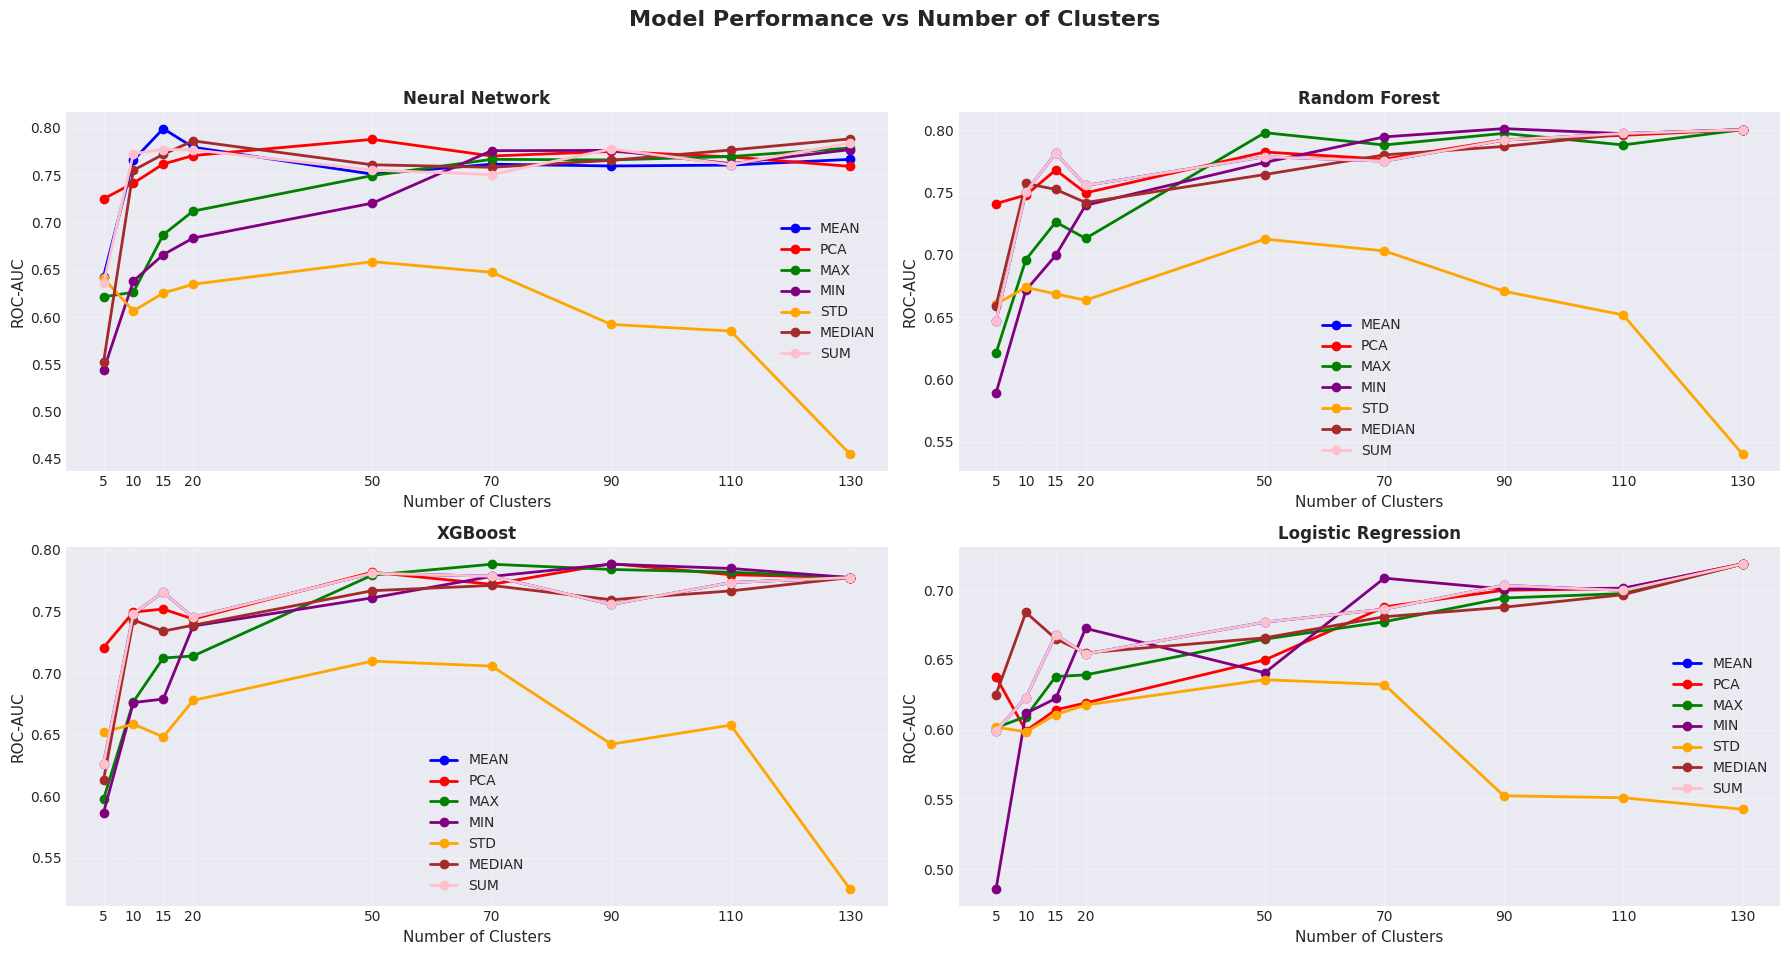

✓ Saved performance plot to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/performance_vs_clusters.png


In [21]:
# ============================================================
# Visualization: Performance vs Number of Clusters
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Model Performance vs Number of Clusters', fontsize=16, fontweight='bold')

models = ['Neural Network', 'Random Forest', 'XGBoost', 'Logistic Regression']
colors = {'mean': 'blue', 'pca': 'red', 'max': 'green', 'min': 'purple', 'std': 'orange', 'median': 'brown', 'sum': 'pink'}

axes_flat = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes_flat[idx]
    model_results = results_df[results_df['model'] == model_name]
    
    for agg_method in AGGREGATION_METHODS:
        agg_results = model_results[model_results['aggregation'] == agg_method]
        agg_results = agg_results.sort_values('n_clusters')
        
        ax.plot(agg_results['n_clusters'], agg_results['roc_auc'], 
                marker='o', label=f'{agg_method.upper()}', color=colors[agg_method], linewidth=2)
    
    ax.set_xlabel('Number of Clusters', fontsize=11)
    ax.set_ylabel('ROC-AUC', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(CLUSTER_LEVELS)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(OUTPUT_DIR / 'performance_vs_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved performance plot to: {OUTPUT_DIR / 'performance_vs_clusters.png'}")


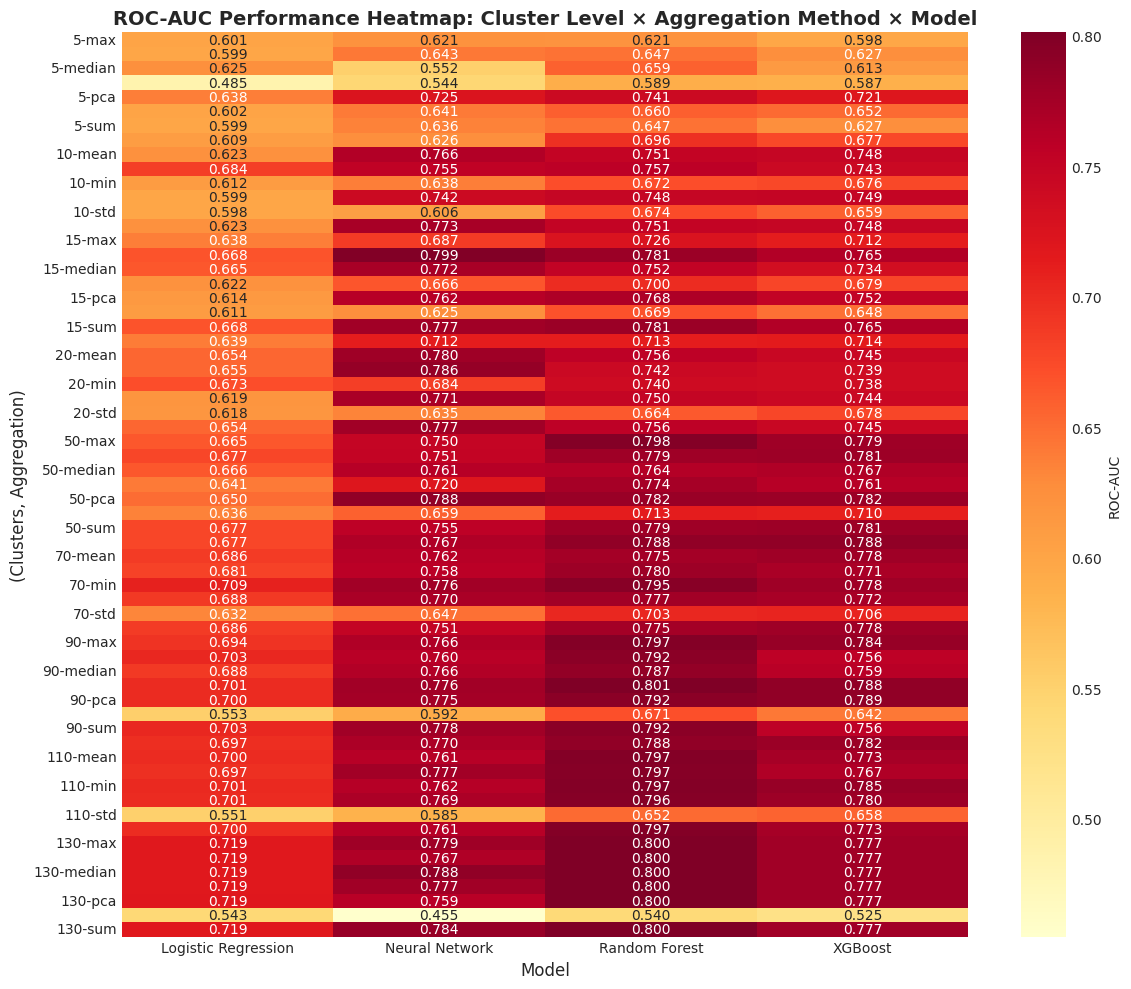

✓ Saved heatmap to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/performance_heatmap.png


In [15]:
# ============================================================
# Visualization: Comparison Heatmap
# ============================================================

# Create pivot table for heatmap
pivot_table = results_df.pivot_table(
    values='roc_auc',
    index=['n_clusters', 'aggregation'],
    columns='model',
    aggfunc='mean'
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'ROC-AUC'})
plt.title('ROC-AUC Performance Heatmap: Cluster Level × Aggregation Method × Model', 
          fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('(Clusters, Aggregation)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved heatmap to: {OUTPUT_DIR / 'performance_heatmap.png'}")


In [16]:
# ============================================================
# Summary Table: Best Results
# ============================================================

summary_rows = []
for model_name in results_df['model'].unique():
    model_results = results_df[results_df['model'] == model_name]
    best_idx = model_results['roc_auc'].idxmax()
    best = model_results.loc[best_idx]
    
    summary_rows.append({
        'Model': model_name,
        'Best ROC-AUC': f"{best['roc_auc']:.4f}",
        'Best Clusters': int(best['n_clusters']),
        'Best Aggregation': best['aggregation'],
        'N Features': int(best['n_features']),
        'Accuracy': f"{best['accuracy']:.4f}",
        'F1 Score': f"{best['f1']:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 80)
print("SUMMARY: BEST CONFIGURATION FOR EACH MODEL")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

# Save summary
summary_df.to_csv(OUTPUT_DIR / 'summary_best_configurations.csv', index=False)
print(f"\n✓ Saved summary to: {OUTPUT_DIR / 'summary_best_configurations.csv'}")



SUMMARY: BEST CONFIGURATION FOR EACH MODEL
              Model Best ROC-AUC  Best Clusters Best Aggregation  N Features Accuracy F1 Score
     Neural Network       0.7993             15             mean          15   0.6998   0.6899
      Random Forest       0.8012             90              min          90   0.7346   0.7327
            XGBoost       0.7887             90              pca          90   0.7121   0.7130
Logistic Regression       0.7190            130              pca         130   0.6547   0.6333

✓ Saved summary to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/summary_best_configurations.csv


## 12. Fine-Tuning Neural Network: Cluster Levels 13-17

Based on the results, Neural Network performs best at 15 clusters with mean aggregation. This section fine-tunes around that optimal point by testing cluster levels 13, 14, 15, 16, and 17, then analyzes which clusters/features are most important.


In [17]:
# ============================================================
# Fine-Tuning: Perform Clustering for Levels 13, 14, 16, 17
# (Level 15 should already exist from previous clustering)
# ============================================================

print("=" * 80)
print("FINE-TUNING: CLUSTERING FOR LEVELS 13, 14, 16, 17")
print("=" * 80)

# Fine-tuning cluster levels
FINE_TUNE_LEVELS = [13, 14, 16, 17]

# Check if correlation matrix is already computed
if 'corr_matrix' not in globals() or 'corr_dist' not in globals():
    print("\nComputing correlation matrix...")
    corr_matrix, corr_dist = compute_correlation_matrix(X_train_scaled, feature_cols)
else:
    print("\n✓ Using existing correlation matrix")

# Check if clustering_results exists, if not create it
if 'clustering_results' not in globals():
    clustering_results = {}

# Perform clustering for fine-tune levels
for n_clusters in FINE_TUNE_LEVELS:
    if n_clusters in clustering_results:
        print(f"\n✓ Cluster level {n_clusters} already exists, skipping...")
    else:
        print(f"\n{'='*60}")
        print(f"Clustering for level: {n_clusters}")
        print(f"{'='*60}")
        
        # Cluster features
        cluster_labels, linkage_matrix, cluster_df = cluster_features(
            X_train_scaled, feature_cols, n_clusters, 
            corr_matrix=corr_matrix, corr_dist=corr_dist
        )
        
        # Store clustering result
        clustering_results[n_clusters] = {
            'cluster_labels': cluster_labels,
            'linkage_matrix': linkage_matrix,
            'cluster_df': cluster_df
        }
        
        # Save cluster assignments
        cluster_df.to_csv(OUTPUT_DIR / f'cluster_assignments_{n_clusters}.csv', index=False)
        print(f"✓ Saved cluster assignments to: {OUTPUT_DIR / f'cluster_assignments_{n_clusters}.csv'}")

# Also ensure level 15 exists (should already be there from previous cells)
if 15 not in clustering_results:
    print(f"\n{'='*60}")
    print(f"Clustering for level: 15 (missing)")
    print(f"{'='*60}")
    cluster_labels, linkage_matrix, cluster_df = cluster_features(
        X_train_scaled, feature_cols, 15, 
        corr_matrix=corr_matrix, corr_dist=corr_dist
    )
    clustering_results[15] = {
        'cluster_labels': cluster_labels,
        'linkage_matrix': linkage_matrix,
        'cluster_df': cluster_df
    }
    cluster_df.to_csv(OUTPUT_DIR / 'cluster_assignments_15.csv', index=False)

print("\n" + "=" * 80)
print("✓ Fine-tune clustering completed")
print("=" * 80)


FINE-TUNING: CLUSTERING FOR LEVELS 13, 14, 16, 17

✓ Using existing correlation matrix

Clustering for level: 13

Clustering 131 features into 13 clusters...
✓ Features clustered into 13 clusters
  Cluster sizes:
    Cluster 1: 19 features
    Cluster 2: 23 features
    Cluster 3: 15 features
    Cluster 4: 16 features
    Cluster 5: 6 features
    Cluster 6: 3 features
    Cluster 7: 7 features
    Cluster 8: 7 features
    Cluster 9: 5 features
    Cluster 10: 6 features
    ... (showing top 10, 13 total clusters)
✓ Saved cluster assignments to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/cluster_assignments_13.csv

Clustering for level: 14

Clustering 131 features into 14 clusters...
✓ Features clustered into 14 clusters
  Cluster sizes:
    Cluster 1: 19 features
    Cluster 2: 8 features
    Cluster 3: 15 features
    Cluster 4: 15 features
    Cluster 5: 16 features
    Cluster 6: 6 features
    Cluster 7: 3 features
    Cluster 8: 7 features
    Cluster 

In [18]:
# ============================================================
# Fine-Tuning: Train Neural Network for Levels 13-17 with Mean Aggregation
# ============================================================

print("=" * 80)
print("FINE-TUNING: TRAINING NEURAL NETWORK FOR LEVELS 13-17")
print("=" * 80)
print("Aggregation method: mean")
print("=" * 80)

# Fine-tuning cluster levels
FINE_TUNE_LEVELS = [13, 14, 15, 16, 17]
fine_tune_results = []
fine_tune_models = {}  # Store models for feature importance analysis

for n_clusters in FINE_TUNE_LEVELS:
    print(f"\n{'='*80}")
    print(f"CLUSTER LEVEL: {n_clusters}")
    print(f"{'='*80}")
    
    if n_clusters not in clustering_results:
        print(f"  ⚠ Warning: Clustering for level {n_clusters} not found. Skipping...")
        continue
    
    # Get cluster labels
    cluster_labels = clustering_results[n_clusters]['cluster_labels']
    
    # Aggregate features using mean
    agg_method = 'mean'
    print(f"\n  Aggregation method: {agg_method}")
    X_train_agg, X_val_agg, X_test_agg, _ = aggregate_features(
        X_train_scaled, X_val_scaled, X_test_scaled,
        cluster_labels, n_clusters, method=agg_method
    )
    
    input_dim = X_train_agg.shape[1]
    print(f"  ✓ Aggregated features: {len(feature_cols)} → {input_dim} features")
    
    # Standardize aggregated features
    scaler_agg = StandardScaler()
    X_train_agg_scaled = scaler_agg.fit_transform(X_train_agg)
    X_val_agg_scaled = scaler_agg.transform(X_val_agg)
    X_test_agg_scaled = scaler_agg.transform(X_test_agg)
    
    # Clip extreme values
    X_train_agg_scaled = np.clip(X_train_agg_scaled, -8.0, 8.0)
    X_val_agg_scaled = np.clip(X_val_agg_scaled, -8.0, 8.0)
    X_test_agg_scaled = np.clip(X_test_agg_scaled, -8.0, 8.0)
    
    # Train Neural Network
    print(f"  Training Neural Network...")
    try:
        nn_model, nn_history, nn_best_epoch = train_nn_model(
            X_train_agg_scaled, X_val_agg_scaled, y_train_raw, y_val_raw,
            input_dim=input_dim, epochs=40
        )
        nn_metrics, nn_probs = evaluate_nn_model(nn_model, X_test_agg_scaled, y_test_raw)
        
        fine_tune_results.append({
            'n_clusters': n_clusters,
            'aggregation': agg_method,
            'n_features': input_dim,
            'accuracy': nn_metrics['accuracy'],
            'roc_auc': nn_metrics['roc_auc'],
            'f1': nn_metrics['f1'],
            'precision': nn_metrics['precision'],
            'recall': nn_metrics['recall'],
            'best_epoch': nn_best_epoch
        })
        
        # Store model and aggregated data for feature importance analysis
        fine_tune_models[n_clusters] = {
            'model': nn_model,
            'X_train_agg': X_train_agg_scaled,
            'X_val_agg': X_val_agg_scaled,
            'X_test_agg': X_test_agg_scaled,
            'cluster_labels': cluster_labels,
            'cluster_df': clustering_results[n_clusters]['cluster_df']
        }
        
        print(f"    ✓ NN - Test Acc: {nn_metrics['accuracy']:.4f}, ROC-AUC: {nn_metrics['roc_auc']:.4f}, F1: {nn_metrics['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ NN failed: {str(e)}")
        import traceback
        traceback.print_exc()

# Convert to DataFrame
fine_tune_df = pd.DataFrame(fine_tune_results)
print("\n" + "=" * 80)
print("FINE-TUNING RESULTS")
print("=" * 80)
print(fine_tune_df.to_string(index=False))
print("=" * 80)

# Save results
fine_tune_df.to_csv(OUTPUT_DIR / 'fine_tune_results_13_17.csv', index=False)
print(f"\n✓ Saved fine-tuning results to: {OUTPUT_DIR / 'fine_tune_results_13_17.csv'}")

# Find best configuration
best_idx = fine_tune_df['roc_auc'].idxmax()
best_config = fine_tune_df.loc[best_idx]
print(f"\n✓ Best configuration:")
print(f"  Cluster level: {best_config['n_clusters']}")
print(f"  ROC-AUC: {best_config['roc_auc']:.4f}")
print(f"  Accuracy: {best_config['accuracy']:.4f}")
print(f"  F1: {best_config['f1']:.4f}")


FINE-TUNING: TRAINING NEURAL NETWORK FOR LEVELS 13-17
Aggregation method: mean

CLUSTER LEVEL: 13

  Aggregation method: mean
  ✓ Aggregated features: 131 → 13 features
  Training Neural Network...
  Early stopping at epoch 23
    ✓ NN - Test Acc: 0.7049, ROC-AUC: 0.7842, F1: 0.7043

CLUSTER LEVEL: 14

  Aggregation method: mean
  ✓ Aggregated features: 131 → 14 features
  Training Neural Network...
  Early stopping at epoch 30
    ✓ NN - Test Acc: 0.7305, ROC-AUC: 0.8079, F1: 0.7252

CLUSTER LEVEL: 15

  Aggregation method: mean
  ✓ Aggregated features: 131 → 15 features
  Training Neural Network...
  Early stopping at epoch 25
    ✓ NN - Test Acc: 0.7029, ROC-AUC: 0.7906, F1: 0.6868

CLUSTER LEVEL: 16

  Aggregation method: mean
  ✓ Aggregated features: 131 → 16 features
  Training Neural Network...
  Early stopping at epoch 36
    ✓ NN - Test Acc: 0.7131, ROC-AUC: 0.7866, F1: 0.7077

CLUSTER LEVEL: 17

  Aggregation method: mean
  ✓ Aggregated features: 131 → 17 features
  Training 

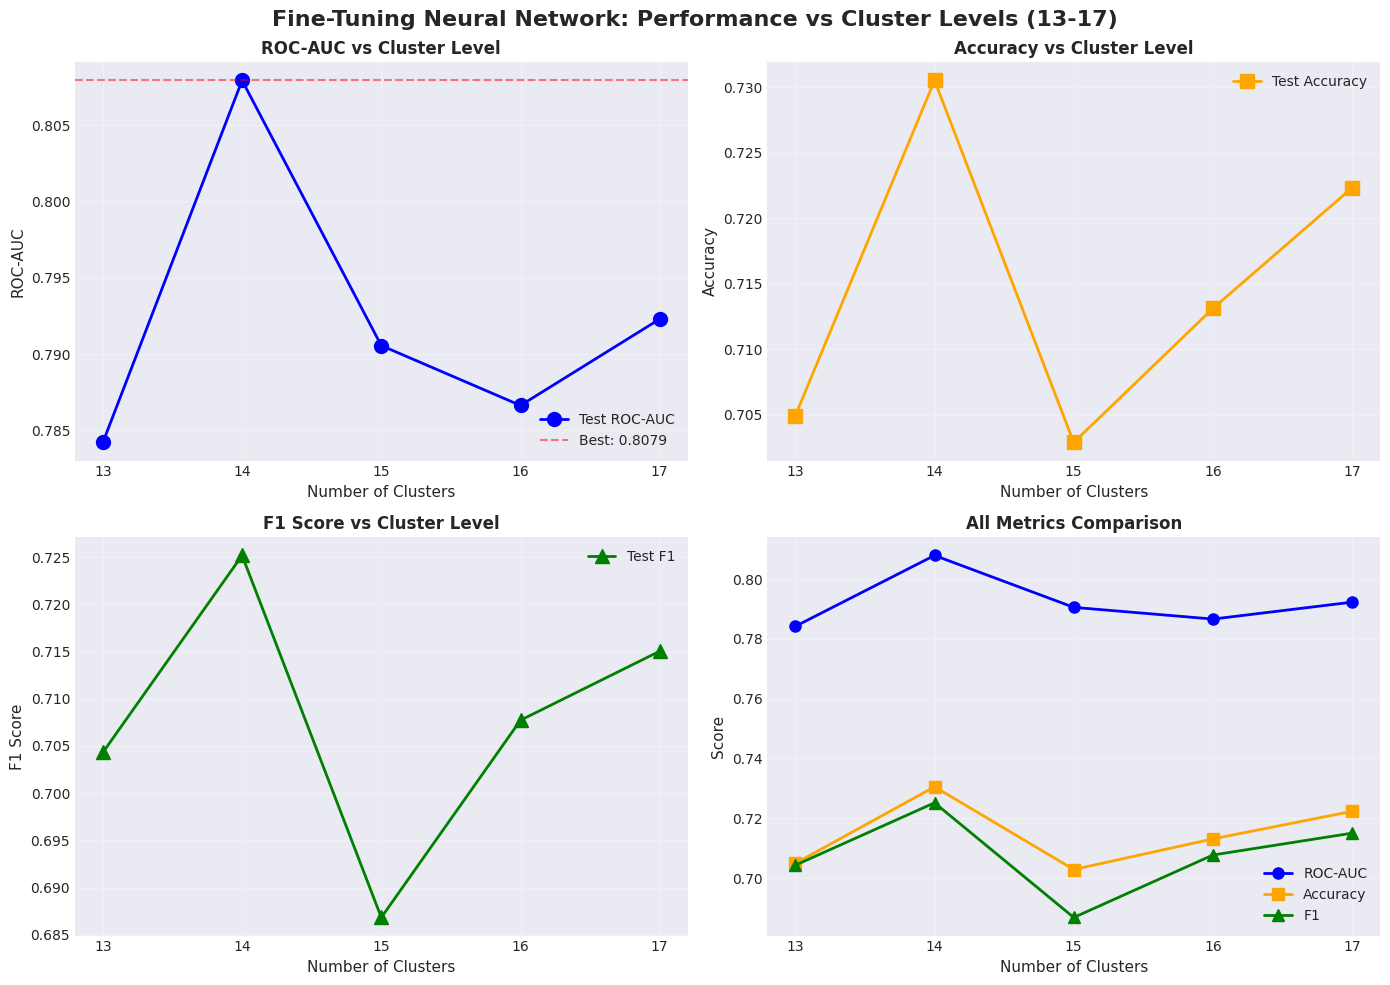

✓ Saved fine-tuning plot to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/fine_tune_performance_13_17.png


In [19]:
# ============================================================
# Visualization: Fine-Tuning Results Comparison
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fine-Tuning Neural Network: Performance vs Cluster Levels (13-17)', 
             fontsize=16, fontweight='bold')

# Sort by cluster level
fine_tune_sorted = fine_tune_df.sort_values('n_clusters')

# 1. ROC-AUC
ax = axes[0, 0]
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['roc_auc'], 
        marker='o', linewidth=2, markersize=10, label='Test ROC-AUC', color='blue')
ax.axhline(y=fine_tune_df['roc_auc'].max(), color='r', linestyle='--', alpha=0.5, 
           label=f"Best: {fine_tune_df['roc_auc'].max():.4f}")
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('ROC-AUC vs Cluster Level', fontsize=12, fontweight='bold')
ax.set_xticks(FINE_TUNE_LEVELS)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Accuracy
ax = axes[0, 1]
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['accuracy'], 
        marker='s', linewidth=2, markersize=10, label='Test Accuracy', color='orange')
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy vs Cluster Level', fontsize=12, fontweight='bold')
ax.set_xticks(FINE_TUNE_LEVELS)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. F1 Score
ax = axes[1, 0]
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['f1'], 
        marker='^', linewidth=2, markersize=10, label='Test F1', color='green')
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 Score vs Cluster Level', fontsize=12, fontweight='bold')
ax.set_xticks(FINE_TUNE_LEVELS)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. All metrics together
ax = axes[1, 1]
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['roc_auc'], 
        marker='o', linewidth=2, markersize=8, label='ROC-AUC', color='blue')
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['accuracy'], 
        marker='s', linewidth=2, markersize=8, label='Accuracy', color='orange')
ax.plot(fine_tune_sorted['n_clusters'], fine_tune_sorted['f1'], 
        marker='^', linewidth=2, markersize=8, label='F1', color='green')
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Metrics Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(FINE_TUNE_LEVELS)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fine_tune_performance_13_17.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved fine-tuning plot to: {OUTPUT_DIR / 'fine_tune_performance_13_17.png'}")


## 13. Feature Importance Analysis for Best Model

This section analyzes which clusters/features are most important in the best performing model using permutation importance.


In [22]:
# ============================================================
# Feature Importance Analysis: Permutation Importance
# ============================================================

def compute_cluster_importance_permutation(model, X_val, y_val, n_clusters, n_iterations=20):
    """
    Compute permutation importance for each cluster/feature.
    
    Parameters:
    -----------
    model : PyTorch model
        Trained model
    X_val : np.ndarray
        Validation features (already aggregated/clustered)
    y_val : np.ndarray
        Validation labels
    n_clusters : int
        Number of clusters (features)
    n_iterations : int
        Number of permutations per feature
        
    Returns:
    --------
    importance_scores : dict
        Dictionary mapping feature index to importance score
    """
    model.eval()
    
    # Baseline score
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
    )
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
    
    # Get baseline predictions
    baseline_probs = []
    baseline_labels = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            baseline_probs.extend(probs)
            baseline_labels.extend(yb.numpy().flatten())
    
    baseline_probs = np.array(baseline_probs)
    baseline_labels = np.array(baseline_labels)
    baseline_score = roc_auc_score(baseline_labels, baseline_probs)
    
    # Compute importance for each feature (cluster)
    importance_scores = {}
    
    print(f"  Computing permutation importance for {n_clusters} clusters (features)...")
    
    for feat_idx in range(n_clusters):
        score_drops = []
        
        for _ in range(n_iterations):
            # Permute this feature
            X_val_permuted = X_val.copy()
            perm_indices = np.random.permutation(len(X_val_permuted))
            X_val_permuted[:, feat_idx] = X_val_permuted[perm_indices, feat_idx]
            
            # Evaluate with permuted feature
            val_dataset_perm = TensorDataset(
                torch.tensor(X_val_permuted, dtype=torch.float32),
                torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
            )
            val_loader_perm = DataLoader(val_dataset_perm, batch_size=128, shuffle=False)
            
            perm_probs = []
            with torch.no_grad():
                for xb, yb in val_loader_perm:
                    xb = xb.to(DEVICE)
                    logits = model(xb)
                    if logits.dim() > 1:
                        logits = logits.squeeze(1)
                    probs = torch.sigmoid(logits).cpu().numpy()
                    perm_probs.extend(probs)
            
            perm_probs = np.array(perm_probs)
            perm_score = roc_auc_score(baseline_labels, perm_probs)
            score_drops.append(baseline_score - perm_score)  # Higher drop = more important
        
        importance_scores[feat_idx] = np.mean(score_drops)
        
        if (feat_idx + 1) % 5 == 0:
            print(f"    Processed {feat_idx + 1}/{n_clusters} clusters...")
    
    print(f"  ✓ Computed importance for all {n_clusters} clusters")
    return importance_scores

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Find best configuration
best_cluster_level = int(best_config['n_clusters'])
print(f"\nAnalyzing feature importance for best model: {best_cluster_level} clusters")
print(f"  ROC-AUC: {best_config['roc_auc']:.4f}")
print(f"  Accuracy: {best_config['accuracy']:.4f}")

# Get best model
if best_cluster_level not in fine_tune_models:
    raise ValueError(f"Model for cluster level {best_cluster_level} not found in fine_tune_models")

best_model_data = fine_tune_models[best_cluster_level]
best_model = best_model_data['model']
X_val_agg = best_model_data['X_val_agg']
cluster_df = best_model_data['cluster_df']

# Convert y_val to numpy array
y_val_np = y_val_raw.values if isinstance(y_val_raw, pd.Series) else y_val_raw

# Compute cluster importance
print(f"\nComputing cluster importance (permutation method)...")
cluster_importance = compute_cluster_importance_permutation(
    best_model, X_val_agg, y_val_np, best_cluster_level, n_iterations=20
)

# Create DataFrame with importance scores
importance_df = pd.DataFrame({
    'cluster_id': range(1, best_cluster_level + 1),
    'feature_index': range(best_cluster_level),
    'importance': [cluster_importance[i] for i in range(best_cluster_level)]
}).sort_values('importance', ascending=False)

print(f"\n✓ Feature importance computed")
print(f"\nTop 10 most important clusters:")
print(importance_df.head(10).to_string(index=False))


FEATURE IMPORTANCE ANALYSIS

Analyzing feature importance for best model: 14 clusters
  ROC-AUC: 0.8079
  Accuracy: 0.7305

Computing cluster importance (permutation method)...
  Computing permutation importance for 14 clusters (features)...
    Processed 5/14 clusters...
    Processed 10/14 clusters...
  ✓ Computed importance for all 14 clusters

✓ Feature importance computed

Top 10 most important clusters:
 cluster_id  feature_index  importance
         12             11    0.093666
          4              3    0.090831
         11             10    0.086411
          6              5    0.045907
         14             13    0.045350
         13             12    0.040729
          1              0    0.030781
          9              8    0.022657
          3              2    0.022649
         10              9    0.021840


In [25]:
# ============================================================
# Analyze Original Features in All Clusters
# ============================================================

print("\n" + "=" * 80)
print("ANALYZING ORIGINAL FEATURES IN ALL CLUSTERS")
print("=" * 80)

# Get all clusters (sorted by importance)
all_clusters = importance_df['cluster_id'].values

print(f"\nAll clusters (sorted by importance):")
print(all_clusters)

# For each cluster, list all original features
print(f"\n{'='*80}")
print("ORIGINAL FEATURES IN ALL CLUSTERS")
print(f"{'='*80}")

features_by_cluster = {}

for cluster_id in all_clusters:
    cluster_features = cluster_df[cluster_df['cluster'] == cluster_id]['feature'].tolist()
    importance_score = importance_df[importance_df['cluster_id'] == cluster_id]['importance'].values[0]
    
    features_by_cluster[cluster_id] = {
        'features': cluster_features,
        'importance': importance_score,
        'n_features': len(cluster_features)
    }
    
    print(f"\nCluster {cluster_id} (Importance: {importance_score:.4f}, N features: {len(cluster_features)}):")
    print(f"  Features: {', '.join(cluster_features)}")

# Create summary of all features
all_features = []
for cluster_id in all_clusters:
    cluster_features = features_by_cluster[cluster_id]['features']
    importance = features_by_cluster[cluster_id]['importance']
    for feat in cluster_features:
        all_features.append({
            'original_feature': feat,
            'cluster_id': cluster_id,
            'cluster_importance': importance
        })

top_features_df = pd.DataFrame(all_features)
top_features_df = top_features_df.sort_values('cluster_importance', ascending=False)

print(f"\n{'='*80}")
print(f"SUMMARY: {len(all_features)} original features across {len(all_clusters)} clusters")
print(f"{'='*80}")

# Save results
importance_df.to_csv(OUTPUT_DIR / f'cluster_importance_{best_cluster_level}clusters.csv', index=False)
top_features_df.to_csv(OUTPUT_DIR / f'top_features_by_cluster_{best_cluster_level}clusters.csv', index=False)

print(f"\n✓ Saved cluster importance to: {OUTPUT_DIR / f'cluster_importance_{best_cluster_level}clusters.csv'}")
print(f"✓ Saved top features to: {OUTPUT_DIR / f'top_features_by_cluster_{best_cluster_level}clusters.csv'}")



ANALYZING ORIGINAL FEATURES IN ALL CLUSTERS

All clusters (sorted by importance):
[12  4 11  6 14 13  1  9  3 10  7  2  5  8]

ORIGINAL FEATURES IN ALL CLUSTERS

Cluster 12 (Importance: 0.0937, N features: 7):
  Features: loudnessPeaksPerSec, VoicedSegmentsPerSec, speaking_rate, articulation_rate, stoi, pesq, si_sdr

Cluster 4 (Importance: 0.0908, N features: 15):
  Features: loudness_sma3_amean, loudness_sma3_percentile20.0, loudness_sma3_percentile50.0, loudness_sma3_percentile80.0, loudness_sma3_pctlrange0-2, loudness_sma3_meanRisingSlope, loudness_sma3_stddevRisingSlope, loudness_sma3_meanFallingSlope, loudness_sma3_stddevFallingSlope, spectralFlux_sma3_amean, spectralFluxV_sma3nz_amean, slopeUV500-1500_sma3nz_amean, spectralFluxUV_sma3nz_amean, equivalentSoundLevel_dBp, mean_intensity_db

Cluster 11 (Importance: 0.0864, N features: 6):
  Features: mfcc4_sma3_amean, slopeV0-500_sma3nz_amean, mfcc4V_sma3nz_amean, std_f1_loc, mean_b1_loc, std_b1_loc

Cluster 6 (Importance: 0.0459, N

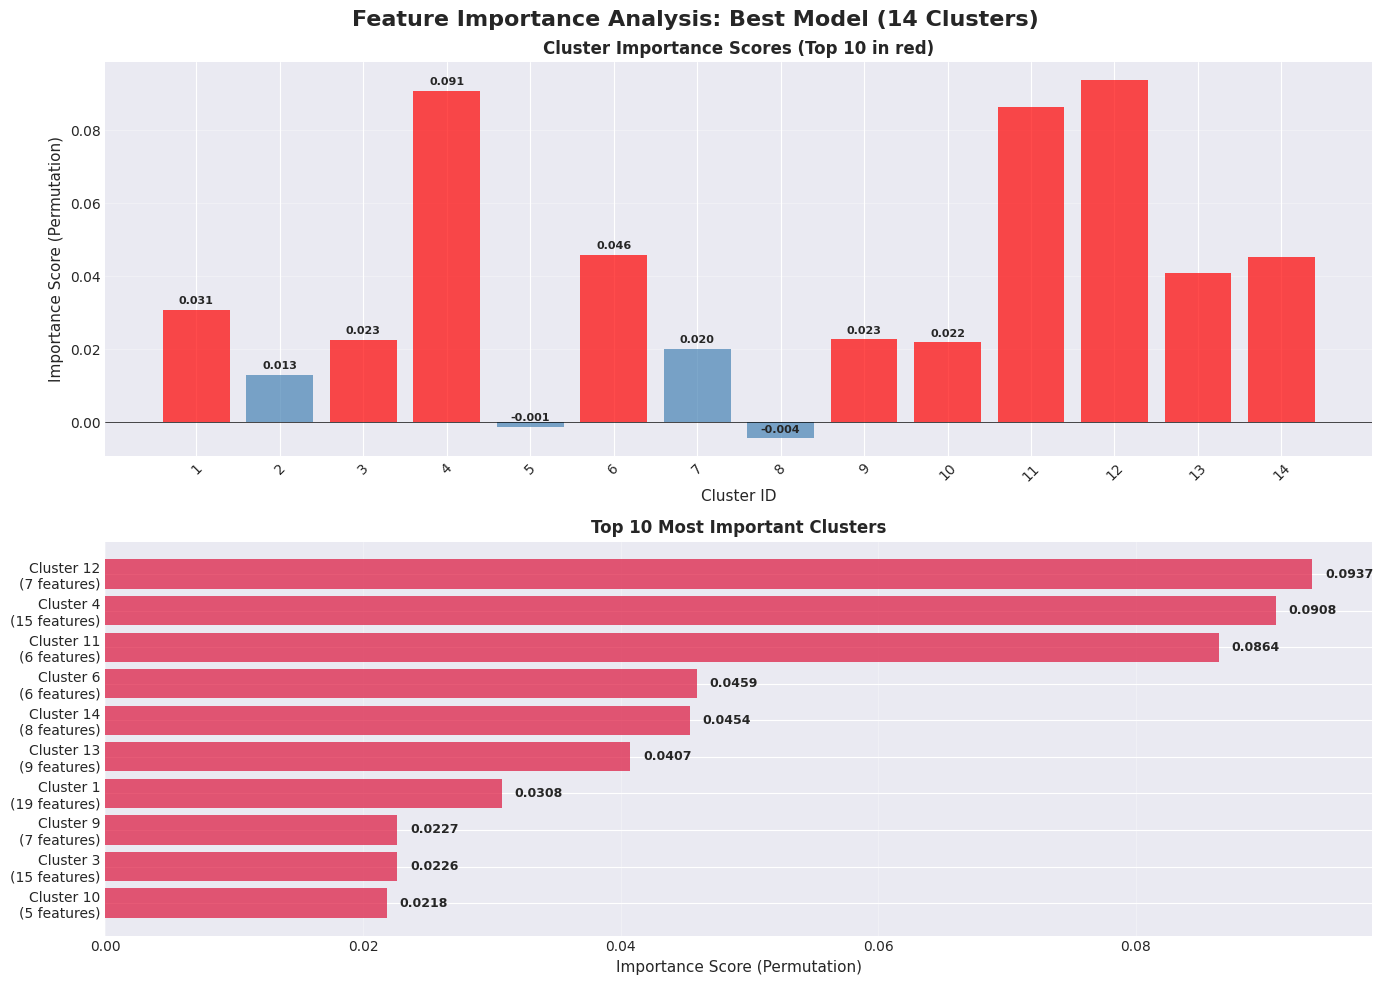

✓ Saved importance plot to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/cluster_importance_14clusters.png


In [24]:
# ============================================================
# Visualization: Cluster Importance
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Feature Importance Analysis: Best Model ({best_cluster_level} Clusters)', 
             fontsize=16, fontweight='bold')

# 1. Bar plot of cluster importance (all clusters)
ax = axes[0]
importance_sorted = importance_df.sort_values('cluster_id')
colors = ['red' if cid in top_clusters else 'steelblue' for cid in importance_sorted['cluster_id']]
bars = ax.bar(range(len(importance_sorted)), importance_sorted['importance'], color=colors, alpha=0.7)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Importance Score (Permutation)', fontsize=11)
ax.set_title(f'Cluster Importance Scores (Top {TOP_N} in red)', fontsize=12, fontweight='bold')
ax.set_xticks(range(0, len(importance_sorted), max(1, len(importance_sorted)//10)))
ax.set_xticklabels(importance_sorted['cluster_id'].values[::max(1, len(importance_sorted)//10)], rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Add value labels on top bars (top clusters only)
for idx, row in importance_sorted.head(TOP_N).iterrows():
    cluster_idx = importance_sorted.index.get_loc(idx)
    ax.text(cluster_idx, row['importance'] + 0.001, f"{row['importance']:.3f}", 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# 2. Top N clusters with feature counts
ax = axes[1]
top_importance = importance_df.head(TOP_N).sort_values('importance', ascending=True)
cluster_labels = [f"Cluster {cid}\n({top_features_by_cluster[cid]['n_features']} features)" 
                  for cid in top_importance['cluster_id']]
bars = ax.barh(range(len(top_importance)), top_importance['importance'], color='crimson', alpha=0.7)
ax.set_yticks(range(len(top_importance)))
ax.set_yticklabels(cluster_labels, fontsize=10)
ax.set_xlabel('Importance Score (Permutation)', fontsize=11)
ax.set_title(f'Top {TOP_N} Most Important Clusters', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for idx, (i, row) in enumerate(top_importance.iterrows()):
    ax.text(row['importance'] + 0.001, idx, f"{row['importance']:.4f}", 
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'cluster_importance_{best_cluster_level}clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved importance plot to: {OUTPUT_DIR / f'cluster_importance_{best_cluster_level}clusters.png'}")


## 13. Patient-Level Prediction from Cluster Features

This section aggregates recording-level cluster features to create patient-level representations and trains models to predict PD vs Control at the patient level.

**Approach:**
1. Use the best cluster configuration (14 clusters with optimal aggregation method)
2. Aggregate recording-level cluster features across all recordings for each patient using multiple methods (mean, median, max, min, std)
3. Create patient-level labels (one label per patient)
4. Train all 4 models (Neural Network, Random Forest, XGBoost, Logistic Regression) on patient-level data
5. Evaluate performance at patient level

This approach allows us to leverage all recordings from each patient while making predictions at the patient level, which is more clinically relevant.


In [26]:
# ============================================================
# Step 1: Get Recording-Level Aggregated Features Using Best Cluster Configuration
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 1 - RECORDING-LEVEL CLUSTER FEATURES")
print("=" * 80)

# Check if best_config exists
if 'best_config' not in globals():
    raise ValueError("best_config not found. Please run the fine-tuning section first.")

best_cluster_level = int(best_config['n_clusters'])
best_agg_method = best_config['aggregation']

print(f"\nUsing best configuration:")
print(f"  Cluster level: {best_cluster_level}")
print(f"  Aggregation method: {best_agg_method}")
print(f"  ROC-AUC: {best_config['roc_auc']:.4f}")

# Get cluster labels for best configuration
if best_cluster_level not in clustering_results:
    raise ValueError(f"Clustering results for {best_cluster_level} clusters not found.")

cluster_labels = clustering_results[best_cluster_level]['cluster_labels']
print(f"\n✓ Retrieved cluster labels for {best_cluster_level} clusters")

# Aggregate features for all recordings using best aggregation method
print(f"\nAggregating features using '{best_agg_method}' method...")
X_train_agg_recording, X_val_agg_recording, X_test_agg_recording, _ = aggregate_features(
    X_train_scaled, X_val_scaled, X_test_scaled,
    cluster_labels, best_cluster_level, method=best_agg_method
)

print(f"✓ Recording-level aggregated features:")
print(f"  Train: {X_train_agg_recording.shape} (n_recordings, n_clusters)")
print(f"  Val:   {X_val_agg_recording.shape}")
print(f"  Test:  {X_test_agg_recording.shape}")

# Store participant IDs for each split (these should already exist from earlier)
print(f"\n✓ Participant IDs available for grouping")
print(f"  Train participants: {len(np.unique(pid_train))}")
print(f"  Val participants:   {len(np.unique(pid_val))}")
print(f"  Test participants:  {len(np.unique(pid_test))}")


PATIENT-LEVEL PREDICTION: STEP 1 - RECORDING-LEVEL CLUSTER FEATURES

Using best configuration:
  Cluster level: 14
  Aggregation method: mean
  ROC-AUC: 0.8079

✓ Retrieved cluster labels for 14 clusters

Aggregating features using 'mean' method...
✓ Recording-level aggregated features:
  Train: (3071, 14) (n_recordings, n_clusters)
  Val:   (832, 14)
  Test:  (976, 14)

✓ Participant IDs available for grouping
  Train participants: 80
  Val participants:   20
  Test participants:  25


In [27]:
# ============================================================
# Step 2: Aggregate Recordings to Patient Level Using Multiple Methods
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 2 - AGGREGATE RECORDINGS TO PATIENT LEVEL")
print("=" * 80)

def aggregate_recordings_to_patient_level(X_recording_features, participant_ids, aggregation_method='mean'):
    """
    Aggregate recording-level features to patient level.
    
    Parameters:
    -----------
    X_recording_features : np.ndarray, shape (n_recordings, n_features)
        Recording-level feature matrix
    participant_ids : np.ndarray, shape (n_recordings,)
        Participant ID for each recording
    aggregation_method : str
        Method to aggregate: 'mean', 'median', 'max', 'min', 'std'
    
    Returns:
    --------
    X_patient : np.ndarray, shape (n_patients, n_features)
        Patient-level aggregated feature matrix
    patient_ids : np.ndarray, shape (n_patients,)
        Unique participant IDs (sorted)
    """
    unique_patients = np.unique(participant_ids)
    n_patients = len(unique_patients)
    n_features = X_recording_features.shape[1]
    
    X_patient = np.zeros((n_patients, n_features))
    
    for i, patient_id in enumerate(unique_patients):
        # Get all recordings for this patient
        patient_mask = participant_ids == patient_id
        patient_recordings = X_recording_features[patient_mask]
        
        # Aggregate based on method
        if aggregation_method == 'mean':
            X_patient[i] = np.mean(patient_recordings, axis=0)
        elif aggregation_method == 'median':
            X_patient[i] = np.median(patient_recordings, axis=0)
        elif aggregation_method == 'max':
            X_patient[i] = np.max(patient_recordings, axis=0)
        elif aggregation_method == 'min':
            X_patient[i] = np.min(patient_recordings, axis=0)
        elif aggregation_method == 'std':
            X_patient[i] = np.std(patient_recordings, axis=0)
        else:
            raise ValueError(f"Unknown aggregation method: {aggregation_method}")
    
    return X_patient, unique_patients

# Define aggregation methods to try
PATIENT_AGG_METHODS = ['mean', 'median', 'max', 'min', 'std']

print(f"\nAggregation methods to try: {PATIENT_AGG_METHODS}")
print(f"\nAggregating recordings to patient level for each method...")

# Store patient-level features for each aggregation method
patient_features_dict = {}

for agg_method in PATIENT_AGG_METHODS:
    print(f"\n  Processing {agg_method} aggregation...")
    
    # Aggregate train/val/test separately
    X_train_patient, pids_train_unique = aggregate_recordings_to_patient_level(
        X_train_agg_recording, pid_train, aggregation_method=agg_method
    )
    X_val_patient, pids_val_unique = aggregate_recordings_to_patient_level(
        X_val_agg_recording, pid_val, aggregation_method=agg_method
    )
    X_test_patient, pids_test_unique = aggregate_recordings_to_patient_level(
        X_test_agg_recording, pid_test, aggregation_method=agg_method
    )
    
    patient_features_dict[agg_method] = {
        'X_train': X_train_patient,
        'X_val': X_val_patient,
        'X_test': X_test_patient,
        'pids_train': pids_train_unique,
        'pids_val': pids_val_unique,
        'pids_test': pids_test_unique
    }
    
    print(f"    Train: {X_train_patient.shape} ({len(pids_train_unique)} patients)")
    print(f"    Val:   {X_val_patient.shape} ({len(pids_val_unique)} patients)")
    print(f"    Test:  {X_test_patient.shape} ({len(pids_test_unique)} patients)")

print(f"\n✓ Patient-level features created for all aggregation methods")


PATIENT-LEVEL PREDICTION: STEP 2 - AGGREGATE RECORDINGS TO PATIENT LEVEL

Aggregation methods to try: ['mean', 'median', 'max', 'min', 'std']

Aggregating recordings to patient level for each method...

  Processing mean aggregation...
    Train: (80, 14) (80 patients)
    Val:   (20, 14) (20 patients)
    Test:  (25, 14) (25 patients)

  Processing median aggregation...
    Train: (80, 14) (80 patients)
    Val:   (20, 14) (20 patients)
    Test:  (25, 14) (25 patients)

  Processing max aggregation...
    Train: (80, 14) (80 patients)
    Val:   (20, 14) (20 patients)
    Test:  (25, 14) (25 patients)

  Processing min aggregation...
    Train: (80, 14) (80 patients)
    Val:   (20, 14) (20 patients)
    Test:  (25, 14) (25 patients)

  Processing std aggregation...
    Train: (80, 14) (80 patients)
    Val:   (20, 14) (20 patients)
    Test:  (25, 14) (25 patients)

✓ Patient-level features created for all aggregation methods


In [28]:
# ============================================================
# Step 3: Create Patient-Level Labels and Prepare Datasets
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 3 - CREATE PATIENT-LEVEL LABELS")
print("=" * 80)

def create_patient_labels(participant_ids, recording_labels):
    """
    Create patient-level labels from recording-level labels.
    Since all recordings from a patient should have the same label,
    we use the first label for each patient (or majority vote if inconsistent).
    
    Parameters:
    -----------
    participant_ids : np.ndarray, shape (n_recordings,)
        Participant ID for each recording
    recording_labels : pd.Series or np.ndarray, shape (n_recordings,)
        Labels for each recording
    
    Returns:
    --------
    patient_labels : np.ndarray, shape (n_patients,)
        Labels for each patient (sorted by participant_id)
    unique_patient_ids : np.ndarray, shape (n_patients,)
        Unique participant IDs (sorted)
    """
    # Convert to numpy if needed
    if isinstance(recording_labels, pd.Series):
        recording_labels = recording_labels.values
    
    unique_patients = np.unique(participant_ids)
    patient_labels = np.zeros(len(unique_patients))
    
    for i, patient_id in enumerate(unique_patients):
        # Get all labels for this patient
        patient_mask = participant_ids == patient_id
        patient_recording_labels = recording_labels[patient_mask]
        
        # Use majority vote (or first label if all are same)
        # In practice, all recordings from a patient should have the same label
        patient_labels[i] = int(np.round(np.mean(patient_recording_labels)))
    
    return patient_labels, unique_patients

# Create patient-level labels for train/val/test
print("\nCreating patient-level labels...")

y_train_patient, pids_train_check = create_patient_labels(pid_train, y_train_raw)
y_val_patient, pids_val_check = create_patient_labels(pid_val, y_val_raw)
y_test_patient, pids_test_check = create_patient_labels(pid_test, y_test_raw)

print(f"\n✓ Patient-level labels created:")
print(f"  Train: {len(y_train_patient)} patients (Control: {(y_train_patient == 0).sum()}, PD: {(y_train_patient == 1).sum()})")
print(f"  Val:   {len(y_val_patient)} patients (Control: {(y_val_patient == 0).sum()}, PD: {(y_val_patient == 1).sum()})")
print(f"  Test:  {len(y_test_patient)} patients (Control: {(y_test_patient == 0).sum()}, PD: {(y_test_patient == 1).sum()})")

# Verify participant IDs match
assert np.array_equal(pids_train_check, patient_features_dict['mean']['pids_train']), "Train participant IDs don't match"
assert np.array_equal(pids_val_check, patient_features_dict['mean']['pids_val']), "Val participant IDs don't match"
assert np.array_equal(pids_test_check, patient_features_dict['mean']['pids_test']), "Test participant IDs don't match"

print("\n✓ Participant IDs verified across all aggregation methods")


PATIENT-LEVEL PREDICTION: STEP 3 - CREATE PATIENT-LEVEL LABELS

Creating patient-level labels...

✓ Patient-level labels created:
  Train: 80 patients (Control: 41, PD: 39)
  Val:   20 patients (Control: 10, PD: 10)
  Test:  25 patients (Control: 13, PD: 12)

✓ Participant IDs verified across all aggregation methods


In [29]:
# ============================================================
# Step 4: Train Models on Patient-Level Data
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 4 - TRAIN MODELS")
print("=" * 80)
print(f"Models: Neural Network, Random Forest, XGBoost, Logistic Regression")
print(f"Patient-level aggregation methods: {PATIENT_AGG_METHODS}")
print("=" * 80)

# Store all patient-level results
patient_level_results = []

# Iterate over patient-level aggregation methods
for patient_agg_method in PATIENT_AGG_METHODS:
    print(f"\n{'='*80}")
    print(f"PATIENT-LEVEL AGGREGATION METHOD: {patient_agg_method.upper()}")
    print(f"{'='*80}")
    
    # Get patient-level features for this aggregation method
    X_train_patient = patient_features_dict[patient_agg_method]['X_train']
    X_val_patient = patient_features_dict[patient_agg_method]['X_val']
    X_test_patient = patient_features_dict[patient_agg_method]['X_test']
    
    # Standardize patient-level features
    scaler_patient = StandardScaler()
    X_train_patient_scaled = scaler_patient.fit_transform(X_train_patient)
    X_val_patient_scaled = scaler_patient.transform(X_val_patient)
    X_test_patient_scaled = scaler_patient.transform(X_test_patient)
    
    # Clip extreme values for neural network
    X_train_patient_scaled = np.clip(X_train_patient_scaled, -8.0, 8.0)
    X_val_patient_scaled = np.clip(X_val_patient_scaled, -8.0, 8.0)
    X_test_patient_scaled = np.clip(X_test_patient_scaled, -8.0, 8.0)
    
    input_dim = X_train_patient_scaled.shape[1]
    print(f"\n✓ Patient-level features shape: {X_train_patient_scaled.shape[0]} patients × {input_dim} features")
    
    # ========== Neural Network ==========
    print(f"\n  Training Neural Network...")
    try:
        nn_model, nn_history, nn_best_epoch = train_nn_model(
            X_train_patient_scaled, X_val_patient_scaled, 
            y_train_patient, y_val_patient,
            input_dim=input_dim, epochs=40
        )
        nn_metrics, nn_probs = evaluate_nn_model(nn_model, X_test_patient_scaled, y_test_patient)
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Neural Network',
            'n_features': input_dim,
            'accuracy': nn_metrics['accuracy'],
            'roc_auc': nn_metrics['roc_auc'],
            'f1': nn_metrics['f1'],
            'precision': nn_metrics['precision'],
            'recall': nn_metrics['recall']
        })
        print(f"    ✓ NN - Test Acc: {nn_metrics['accuracy']:.4f}, ROC-AUC: {nn_metrics['roc_auc']:.4f}, F1: {nn_metrics['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ NN failed: {str(e)}")
    
    # ========== Random Forest ==========
    print(f"  Training Random Forest...")
    try:
        rf_model, rf_val_auc = train_rf_model(
            X_train_patient_scaled, X_val_patient_scaled, 
            y_train_patient, y_val_patient
        )
        rf_metrics, rf_probs = evaluate_sklearn_model(rf_model, X_test_patient_scaled, y_test_patient)
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Random Forest',
            'n_features': input_dim,
            'accuracy': rf_metrics['accuracy'],
            'roc_auc': rf_metrics['roc_auc'],
            'f1': rf_metrics['f1'],
            'precision': rf_metrics['precision'],
            'recall': rf_metrics['recall']
        })
        print(f"    ✓ RF - Test Acc: {rf_metrics['accuracy']:.4f}, ROC-AUC: {rf_metrics['roc_auc']:.4f}, F1: {rf_metrics['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ RF failed: {str(e)}")
    
    # ========== XGBoost ==========
    print(f"  Training XGBoost...")
    try:
        xgb_model, xgb_val_auc = train_xgb_model(
            X_train_patient_scaled, X_val_patient_scaled, 
            y_train_patient, y_val_patient
        )
        xgb_metrics, xgb_probs = evaluate_sklearn_model(xgb_model, X_test_patient_scaled, y_test_patient)
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'XGBoost',
            'n_features': input_dim,
            'accuracy': xgb_metrics['accuracy'],
            'roc_auc': xgb_metrics['roc_auc'],
            'f1': xgb_metrics['f1'],
            'precision': xgb_metrics['precision'],
            'recall': xgb_metrics['recall']
        })
        print(f"    ✓ XGB - Test Acc: {xgb_metrics['accuracy']:.4f}, ROC-AUC: {xgb_metrics['roc_auc']:.4f}, F1: {xgb_metrics['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ XGB failed: {str(e)}")
    
    # ========== Logistic Regression ==========
    print(f"  Training Logistic Regression...")
    try:
        lr_model, lr_val_auc = train_lr_model(
            X_train_patient_scaled, X_val_patient_scaled, 
            y_train_patient, y_val_patient
        )
        lr_metrics, lr_probs = evaluate_sklearn_model(lr_model, X_test_patient_scaled, y_test_patient)
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Logistic Regression',
            'n_features': input_dim,
            'accuracy': lr_metrics['accuracy'],
            'roc_auc': lr_metrics['roc_auc'],
            'f1': lr_metrics['f1'],
            'precision': lr_metrics['precision'],
            'recall': lr_metrics['recall']
        })
        print(f"    ✓ LR - Test Acc: {lr_metrics['accuracy']:.4f}, ROC-AUC: {lr_metrics['roc_auc']:.4f}, F1: {lr_metrics['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ LR failed: {str(e)}")

print(f"\n{'='*80}")
print("PATIENT-LEVEL TRAINING COMPLETE")
print(f"{'='*80}")


PATIENT-LEVEL PREDICTION: STEP 4 - TRAIN MODELS
Models: Neural Network, Random Forest, XGBoost, Logistic Regression
Patient-level aggregation methods: ['mean', 'median', 'max', 'min', 'std']

PATIENT-LEVEL AGGREGATION METHOD: MEAN

✓ Patient-level features shape: 80 patients × 14 features

  Training Neural Network...
  Early stopping at epoch 19
    ✓ NN - Test Acc: 0.7600, ROC-AUC: 0.8590, F1: 0.7500
  Training Random Forest...
    ✓ RF - Test Acc: 0.8000, ROC-AUC: 0.9295, F1: 0.8000
  Training XGBoost...
    ✓ XGB - Test Acc: 0.8000, ROC-AUC: 0.9423, F1: 0.8000
  Training Logistic Regression...
    ✓ LR - Test Acc: 0.8400, ROC-AUC: 0.8974, F1: 0.8333

PATIENT-LEVEL AGGREGATION METHOD: MEDIAN

✓ Patient-level features shape: 80 patients × 14 features

  Training Neural Network...
  Early stopping at epoch 32
    ✓ NN - Test Acc: 0.9200, ROC-AUC: 0.9551, F1: 0.9231
  Training Random Forest...
    ✓ RF - Test Acc: 0.9200, ROC-AUC: 0.9744, F1: 0.9167
  Training XGBoost...
    ✓ XGB - Te

In [30]:
# ============================================================
# Step 5: Summarize and Save Patient-Level Results
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 5 - RESULTS SUMMARY")
print("=" * 80)

# Convert results to DataFrame
patient_level_df = pd.DataFrame(patient_level_results)

if len(patient_level_df) > 0:
    print("\n" + "=" * 80)
    print("PATIENT-LEVEL PREDICTION RESULTS")
    print("=" * 80)
    print(patient_level_df.to_string(index=False))
    print("=" * 80)
    
    # Find best configuration for each model
    print("\n" + "=" * 80)
    print("BEST CONFIGURATION FOR EACH MODEL (Patient-Level)")
    print("=" * 80)
    
    best_patient_results = []
    for model_name in patient_level_df['model'].unique():
        model_results = patient_level_df[patient_level_df['model'] == model_name]
        best_idx = model_results['roc_auc'].idxmax()
        best = model_results.loc[best_idx]
        
        best_patient_results.append({
            'Model': model_name,
            'Best Patient Aggregation': best['patient_aggregation'],
            'ROC-AUC': f"{best['roc_auc']:.4f}",
            'Accuracy': f"{best['accuracy']:.4f}",
            'F1 Score': f"{best['f1']:.4f}",
            'Precision': f"{best['precision']:.4f}",
            'Recall': f"{best['recall']:.4f}",
            'N Features': int(best['n_features'])
        })
    
    best_patient_df = pd.DataFrame(best_patient_results)
    print(best_patient_df.to_string(index=False))
    print("=" * 80)
    
    # Save results
    patient_level_df.to_csv(OUTPUT_DIR / 'patient_level_results.csv', index=False)
    best_patient_df.to_csv(OUTPUT_DIR / 'patient_level_best_configurations.csv', index=False)
    
    print(f"\n✓ Saved patient-level results to: {OUTPUT_DIR / 'patient_level_results.csv'}")
    print(f"✓ Saved best configurations to: {OUTPUT_DIR / 'patient_level_best_configurations.csv'}")
    
    # Summary statistics
    print(f"\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    print(f"Total configurations tested: {len(patient_level_df)}")
    print(f"  - Models: {len(patient_level_df['model'].unique())}")
    print(f"  - Patient aggregation methods: {len(patient_level_df['patient_aggregation'].unique())}")
    print(f"\nBest overall ROC-AUC: {patient_level_df['roc_auc'].max():.4f}")
    best_overall_idx = patient_level_df['roc_auc'].idxmax()
    best_overall = patient_level_df.loc[best_overall_idx]
    print(f"  Model: {best_overall['model']}")
    print(f"  Patient Aggregation: {best_overall['patient_aggregation']}")
    print(f"  Accuracy: {best_overall['accuracy']:.4f}")
    print(f"  F1 Score: {best_overall['f1']:.4f}")
else:
    print("\n⚠ No results to display. Training may have failed.")

print("\n" + "=" * 80)
print("PATIENT-LEVEL PREDICTION ANALYSIS COMPLETE")
print("=" * 80)


PATIENT-LEVEL PREDICTION: STEP 5 - RESULTS SUMMARY

PATIENT-LEVEL PREDICTION RESULTS
patient_aggregation               model  n_features  accuracy  roc_auc       f1  precision   recall
               mean      Neural Network          14      0.76 0.858974 0.750000   0.750000 0.750000
               mean       Random Forest          14      0.80 0.929487 0.800000   0.769231 0.833333
               mean             XGBoost          14      0.80 0.942308 0.800000   0.769231 0.833333
               mean Logistic Regression          14      0.84 0.897436 0.833333   0.833333 0.833333
             median      Neural Network          14      0.92 0.955128 0.923077   0.857143 1.000000
             median       Random Forest          14      0.92 0.974359 0.916667   0.916667 0.916667
             median             XGBoost          14      0.88 0.974359 0.880000   0.846154 0.916667
             median Logistic Regression          14      0.84 0.910256 0.818182   0.900000 0.750000
               

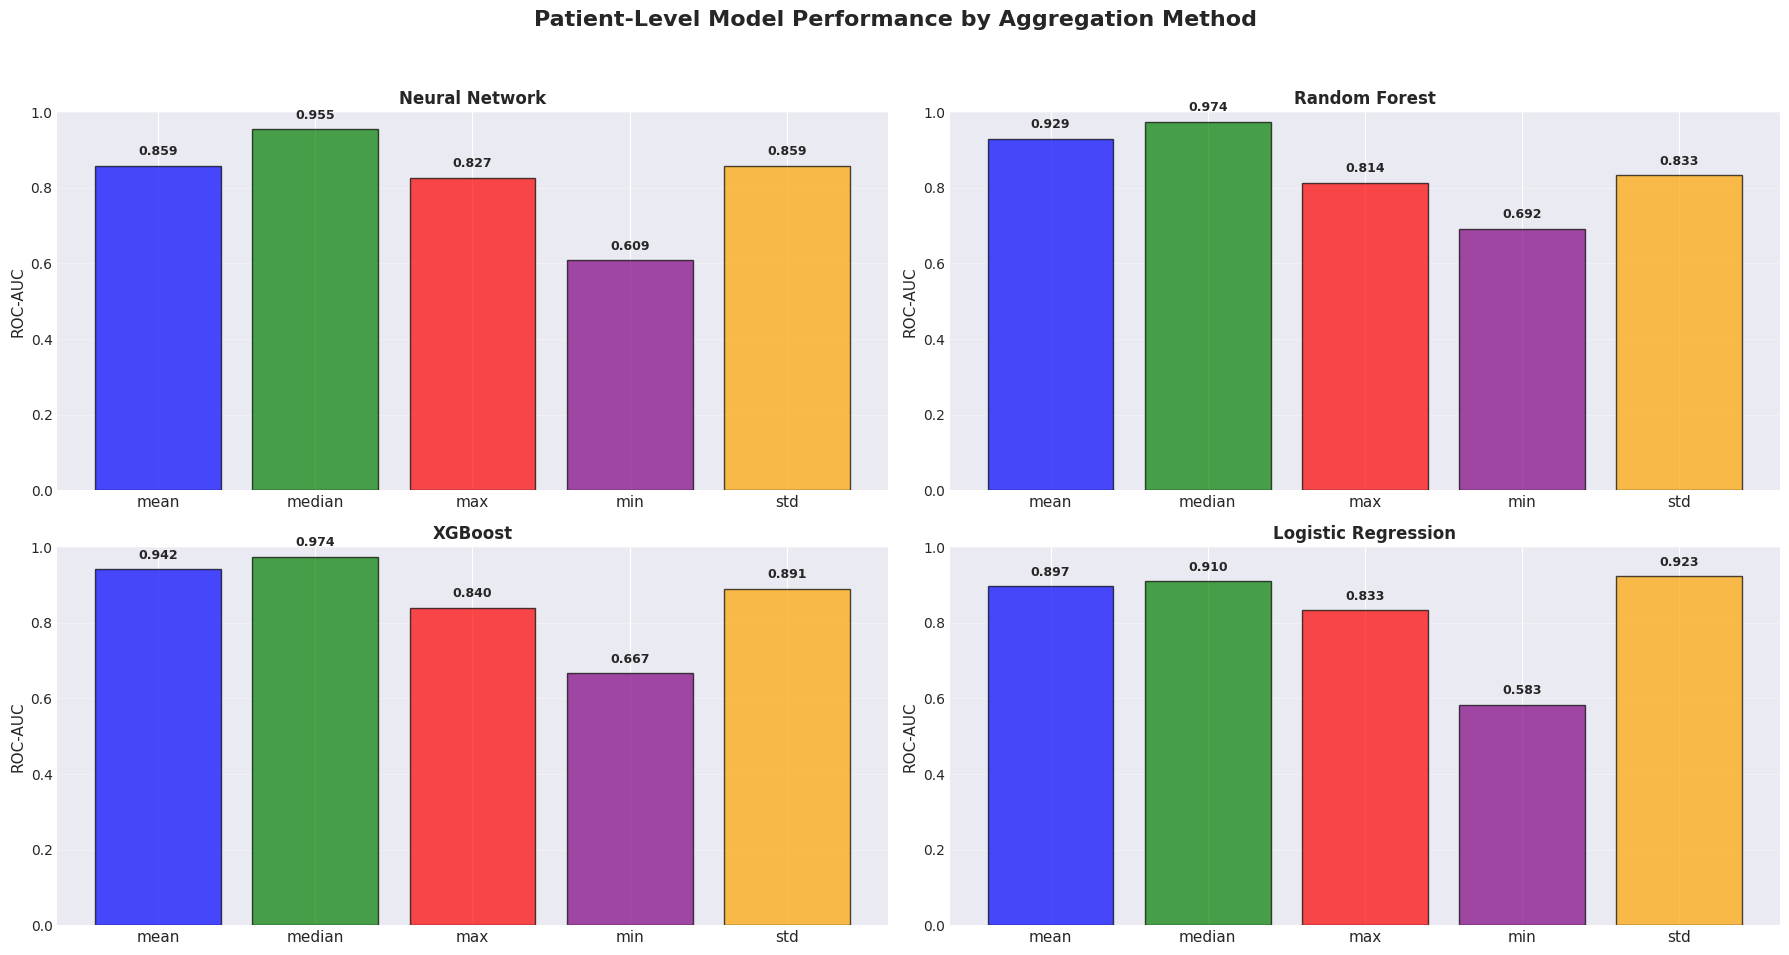

✓ Saved patient-level performance comparison to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/patient_level_performance_comparison.png


In [31]:
# ============================================================
# Visualization: Patient-Level Results by Aggregation Method
# ============================================================

if len(patient_level_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle('Patient-Level Model Performance by Aggregation Method', fontsize=16, fontweight='bold')
    
    models = ['Neural Network', 'Random Forest', 'XGBoost', 'Logistic Regression']
    colors = {'mean': 'blue', 'median': 'green', 'max': 'red', 'min': 'purple', 'std': 'orange'}
    
    axes_flat = axes.flatten()
    
    for idx, model_name in enumerate(models):
        ax = axes_flat[idx]
        model_results = patient_level_df[patient_level_df['model'] == model_name]
        
        if len(model_results) > 0:
            x_pos = np.arange(len(PATIENT_AGG_METHODS))
            bars = []
            
            for agg_method in PATIENT_AGG_METHODS:
                agg_results = model_results[model_results['patient_aggregation'] == agg_method]
                if len(agg_results) > 0:
                    roc_auc = agg_results['roc_auc'].values[0]
                    bars.append(roc_auc)
                else:
                    bars.append(0)
            
            ax.bar(x_pos, bars, color=[colors[method] for method in PATIENT_AGG_METHODS], alpha=0.7, edgecolor='black')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(PATIENT_AGG_METHODS, fontsize=11)
            ax.set_ylabel('ROC-AUC', fontsize=11)
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim([0, 1.0])
            
            # Add value labels on bars
            for i, v in enumerate(bars):
                if v > 0:
                    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'No results for {model_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'patient_level_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved patient-level performance comparison to: {OUTPUT_DIR / 'patient_level_performance_comparison.png'}")
else:
    print("⚠ No results to visualize. Please run the training cell first.")


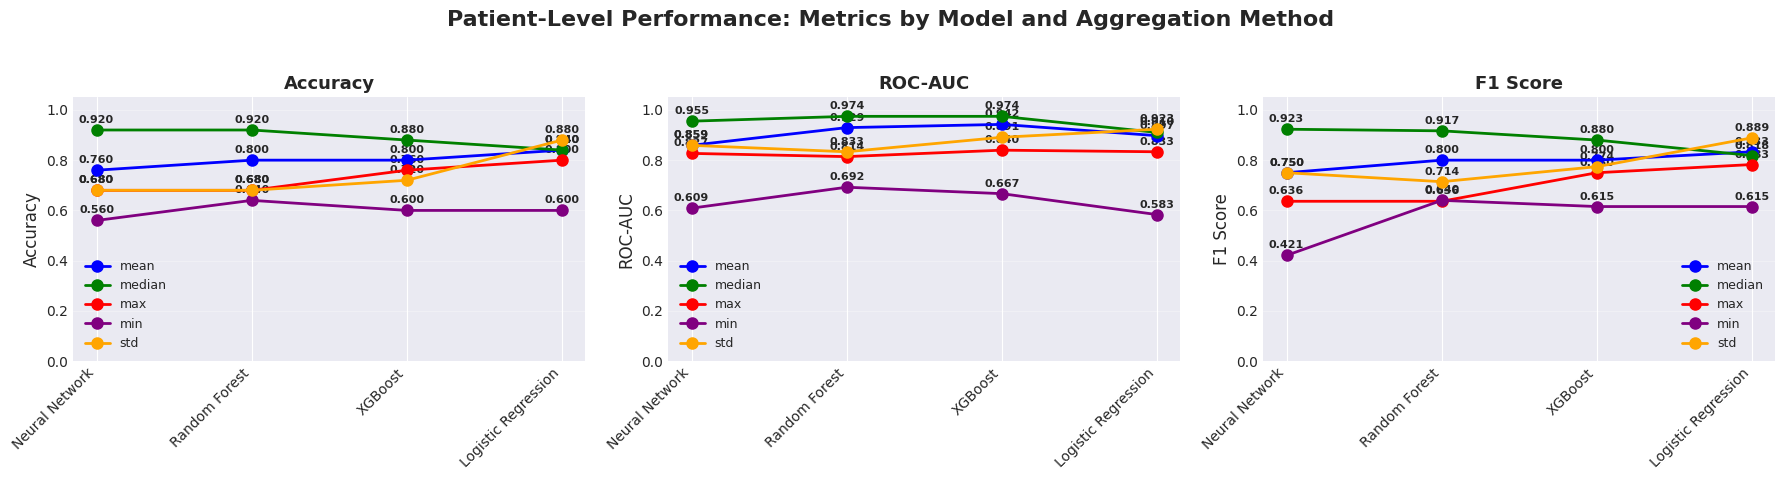

✓ Saved line chart visualization to: /home/Phenotype and Voice for PD/outputs/cluster_feature_engineering/patient_level_metrics_line_charts.png


In [33]:
# ============================================================
# Line Chart Visualization: Test Metrics by Aggregation Method
# ============================================================

if len(patient_level_df) > 0:
    metrics = ['accuracy', 'roc_auc', 'f1']
    metric_labels = ['Accuracy', 'ROC-AUC', 'F1 Score']
    models = ['Neural Network', 'Random Forest', 'XGBoost', 'Logistic Regression']
    colors = {'mean': 'blue', 'median': 'green', 'max': 'red', 'min': 'purple', 'std': 'orange'}
    
    # Create figure with 3 subplots (one for each metric)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Patient-Level Performance: Metrics by Model and Aggregation Method', fontsize=16, fontweight='bold')
    
    # X-axis positions for models
    x_positions = np.arange(len(models))
    
    # Iterate over metrics
    for metric_idx, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[metric_idx]
        
        # Plot a line for each aggregation method
        for agg_method in PATIENT_AGG_METHODS:
            agg_values = []
            for model_name in models:
                model_results = patient_level_df[patient_level_df['model'] == model_name]
                agg_results = model_results[model_results['patient_aggregation'] == agg_method]
                if len(agg_results) > 0:
                    agg_values.append(agg_results[metric].values[0])
                else:
                    agg_values.append(np.nan)
            
            # Plot line connecting all models for this aggregation method
            valid_mask = ~np.isnan(agg_values)
            if valid_mask.any():
                ax.plot(x_positions[valid_mask], np.array(agg_values)[valid_mask], 
                       marker='o', color=colors[agg_method], label=agg_method,
                       linewidth=2, markersize=8, zorder=5)
                
                # Add value labels on points
                for i, val in enumerate(agg_values):
                    if not np.isnan(val):
                        ax.text(i, val + 0.02, f'{val:.3f}', 
                               ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(models, fontsize=10, rotation=45, ha='right')
        ax.set_ylabel(metric_label, fontsize=12)
        ax.set_title(metric_label, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 1.05])
        ax.legend(loc='best', fontsize=9, ncol=1)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'patient_level_metrics_line_charts.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved line chart visualization to: {OUTPUT_DIR / 'patient_level_metrics_line_charts.png'}")
else:
    print("⚠ No results to visualize. Please run the training cell first.")
